# MAGIC dataset

## Import libraries and load MAGIC dataset

In [3]:
import math
import time
import numpy as np
import pandas as pd
import random as rnd
from matplotlib import pyplot as plt

from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

import shap
import optuna

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import roc_curve, precision_recall_curve, f1_score, auc
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    log_loss
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier
#from sklearn.calibration import CalibratedClassifierCV
#from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import joblib
import warnings
#warnings.filterwarnings("ignore", message="X does not have valid feature names") # to silence harmless LightGBM warning
#tf.get_logger().setLevel('ERROR') # to silence harmless keras input warning

We use the [MAGIC dataset](https://archive.ics.uci.edu/dataset/159/magic+gamma+telescope), a benchmark Machine learning binary classification task.

Each sample presents 10 geometrical features calculated from an individual (preprocessed) image of the hadronic "shower" recorded (in UV wavelength) by a ground-based telescope. (Typically, the image of a shower after some pre-processing is an elongated cluster). The task consists in classifying each shower (sample) as either caused by a high-energy gamma ray (signal) or a generic cosmic ray (background) colliding with particles in Earth's upper atmosphere. (All samples in this datasets are generated via Monte Carlo methods, and SNR is higher than in real life as to make the classification task easier).

In [4]:
def load_dataset(filename):
    data_train = pd.read_csv(filename,sep=",", names = [
    'fLength', 'fWidth', 'fSize', 'fConc', 'fConc1',
    'fAsym', 'fM3Long', 'fM3Trans', 'fAlpha', 'fDist', 'class'
    ])
    #permute the data
    data_train = data_train.sample(frac=1).reset_index(drop=True) # shuffle the data
    X = data_train.iloc[:, 0:10].values # Get first two columns as the input
    Y = data_train.iloc[:, 10].values # Get the third column as the label
    Y[Y=="g"]=1
    Y[Y=="h"]=0
    Y = Y.astype(int)
    return X,Y

feature_names = ['fLength','fWidth','fSize','fConc','fConc1',
                 'fAsym','fM3Long','fM3Trans','fAlpha','fDist']

# Load the dataset
X, Y = load_dataset("https://archive.ics.uci.edu/ml/machine-learning-databases/magic/magic04.data")

# Division between test and train dataset
rng = rnd.Random(42)
idx = list(range(X.shape[0]))
test_idx = rng.sample(idx, int(X.shape[0]*0.25))
train_idx = [i for i in idx if i not in test_idx]
X_training = X[train_idx]
X_test  = X[test_idx]
Y_training = Y[train_idx]
Y_test  = Y[test_idx]

# Validation set definition
idx = list(range(X_training.shape[0]))
val_idx = rng.sample(idx, int(X_training.shape[0]*0.25))
train_idx = [i for i in idx if i not in val_idx]
X_val  = X_training[val_idx]
X_training = X_training[train_idx]
Y_val  = Y_training[val_idx]
Y_training = Y_training[train_idx]

In [5]:
ratio = float(np.sum(Y_training == 0)) / np.sum(Y_training == 1) # unbalance between samples of different classes

In [6]:
print(1/ratio) # optimal value of scale_pos_weight (see later)

1.8432102046239702


## Hyperparameters optimization for boosted forest models

### Random forest classifier for baseline comparison

In [7]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf.fit(X_training, Y_training)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]
roc_auc_clean_rf=roc_auc_score(Y_test, y_prob_rf)
acc_clean_rf=accuracy_score(Y_test, y_pred_rf)
err_clean_rf=1-acc_clean_rf

print(f"RANDOM FOREST BASELINE (default params)")
print(f"ROC AUC:  {roc_auc_clean_rf:.4f}")
print(f"Accuracy: {acc_clean_rf:.4f}")
print(f"0-1 Loss: {err_clean_rf:.4f}")

RANDOM FOREST BASELINE (default params)
ROC AUC:  0.9334
Accuracy: 0.8759
0-1 Loss: 0.1241


### Gradient Boost

Standard gradient boosting is a tree-based binary classification model that uses _boosting_, _i.e._ it sequentially adds decision trees, each correcting the residuals of the previous ensemble.

It offers classic hyperparameters that control complexity and speed:
* `n_estimators`: number of boosting stages (trees). More trees increase capacity but may overfit
* `learning_rate`: multiplicative factor (step size) that shrinks the contribution of each new tree before adding it to the ensemble; lower values demand more iterations but often generalize better`
* `max_depth`: maximum depth of each tree; deeper trees capture more interactions but overfit easily
* `subsample`: fraction of samples used for fitting each tree (stochastic gradient boosting). Values < 1.0 add randomness and can improve generalization
* `max_features`: fraction of features considered when looking for the best split
* `min_samples_split` and `min_samples_leaf`: minimum number of samples required to split an internal node or to be at a leaf node; both act as regularizers
* `class_weight`: to account for imbalance between classes.

We optimize these using Optuna (see below for the explanation) with 5‑fold stratified cross validation (CV) using 0-1 loss, and evaluate using ROC‑AUC score (see below).

Note that for this problem we use ROC-AUC score (_Receiver Operating Characteristic - Area Under Curve_), a metric for binary classifiers.
It is defined as the area under the curve of true positives rate as a function of false positive rates; therefore, it penalizes false positives. In our case this is necessary, as classifying background as signal is considered worse, from a scientific point of view, than missing out on a real signal.
ROC-AUC varies from 0 to 1, 1 with 1 being perfect classification and 0.5 a random guess.

In practice, for tree models, given a set of predicted probabilities of the sample belonging to class 1 (which range continuously from 0 to 1), and the corresponding true labels of the samples, this curve is computed by varying the _decision threshold_ of the model, _i.e._ the threshold above which a sample is classified as belonging to class 1 (and not to class 0), for the simple reason that by doing so the false positive rate can change from 0 to 1.

In [8]:
def objective(trial):
    #scale_pos_weight = trial.suggest_float('scale_pos_weight', 0.5, 1.5, log=True) # note: defined by us

    params = {
        'loss': 'log_loss',
        'random_state': 42,
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),          # reduced range
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'max_features': trial.suggest_float('max_features', 0.5, 1.0),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        #'class_weight': {0: 1.0, 1: scale_pos_weight},

        # early stopping using loss - no simple way to use ROCAUC here
        'validation_fraction': 0.1,   # hold out 10% of each fold's training data
        'n_iter_no_change': 10,       # stop if no improvement for 10 iterations
        'tol': 1e-4,                  # minimum required improvement
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    for train_idx, val_idx in cv.split(X_training, Y_training):
        X_tr, X_vl = X_training[train_idx], X_training[val_idx]
        y_tr, y_vl = Y_training[train_idx], Y_training[val_idx]
        model = GradientBoostingClassifier(**params)
        model.fit(X_tr, y_tr)
        scores.append(roc_auc_score(y_vl, model.predict_proba(X_vl)[:, 1]))
    return np.mean(scores)

study_gbm = optuna.create_study(direction='maximize')

[I 2026-05-17 16:14:52,858] A new study created in memory with name: no-name-2bd71873-11ba-4a94-ad95-ec01d798fab8


In [9]:
i=time.time()
study_gbm.optimize(objective, n_trials=50, show_progress_bar=True)   # fewer trials, fast convergence
f=time.time()
elapsed_gbm=f-i
print(f"Training completed in {elapsed_gbm:.1f} seconds.")

# Final training with best params + early stopping
best_gbm = GradientBoostingClassifier(
    loss='log_loss',
    random_state=42,
    validation_fraction=0.2,
    n_iter_no_change=10,        # stop early if no gain
    tol=1e-4,
    **study_gbm.best_params
)
best_gbm.fit(X_training, Y_training)

y_pred_gbm = best_gbm.predict(X_test)
y_prob_gbm = best_gbm.predict_proba(X_test)[:, 1]
roc_auc_clean_gbm=roc_auc_score(Y_test, y_prob_gbm)
acc_clean_gbm=accuracy_score(Y_test, y_pred_gbm)
err_clean_gbm=1-acc_clean_gbm

print(f"GradientBoosting Test AUC: {roc_auc_clean_gbm:.4f}")

roc_auc_clean_gbm=roc_auc_score(Y_test, y_prob_gbm)

  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-17 16:15:00,529] Trial 0 finished with value: 0.9273009464170989 and parameters: {'n_estimators': 85, 'learning_rate': 0.028219010975621538, 'max_depth': 9, 'subsample': 0.6405361022805793, 'max_features': 0.7807968691242941, 'min_samples_split': 12, 'min_samples_leaf': 19}. Best is trial 0 with value: 0.9273009464170989.
[I 2026-05-17 16:15:09,353] Trial 1 finished with value: 0.9262419193753582 and parameters: {'n_estimators': 153, 'learning_rate': 0.04256714006580865, 'max_depth': 4, 'subsample': 0.7215841814099888, 'max_features': 0.8059107122474545, 'min_samples_split': 15, 'min_samples_leaf': 7}. Best is trial 0 with value: 0.9273009464170989.
[I 2026-05-17 16:15:11,753] Trial 2 finished with value: 0.8827779416441672 and parameters: {'n_estimators': 53, 'learning_rate': 0.023361539638117886, 'max_depth': 3, 'subsample': 0.7232265944183427, 'max_features': 0.8285656758304663, 'min_samples_split': 14, 'min_samples_leaf': 13}. Best is trial 0 with value: 0.92730094641709

### XGBoost

XGBoost is a boosted tree-based classification model that, as an improvement of standard Gradient Boosting, makes use of regularization, pruning, and second derivatives of the loss function (for evaluating the best split), along with other algorithmic improvements aimed at improving classification accuracy.

With regard to computational complexity, training is made much faster by parallel evaluation of all features, histogram-based splitting (_i.e._ continuous features are discretised by means of a certain number of bins), cache-friendly storage of intermediate results, and the fact that the code is written in C++ (instead of standard Python / CPython like Gradient Boost).

The hyperparameters involved in this model are:

- `max_depth`: same as before (GradientBoost)
- `min_child_weight`: parameter to regulate the minimum amount of points needed to add another node to the decision tree; regulates overfitting by avoiding to split over very small groups of points (same as `min_samples_split` in GradientBoost)
- `learning rate`: same as before
- `n_estimators`: samea as before
- `subsample` and `colsample_bytree`: percentage of rows (samples) or of columns (features) used by each tree, with a similar concept used in random forests with _bagging_. Same to, respectively, `subsample` and `max_features` in GradientBoost
- `gamma`: parameter to regulate _pruning_; with a high value the code will favor a simpler solution rather then a slightly more accurate one
- `reg_lambda`: parameter to regulate model complexity - it is the multiplicative constant of the L-2 regularization term
- `scale_pos_weight`: weight for the positive class; compensates for class imbalance by up-weighting the minority class

#### Performance with basic hyperparameters

In [10]:
# Parameters configuration
model = xgb.XGBClassifier(
    booster="gbtree",            # weak learner used as a base
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,                 # depth of trees
    subsample=0.8,               # 80% of rows
    colsample_bytree=0.8,        # 80% of columns
    scale_pos_weight=ratio,      # parameter that accounts for the inbalance of classes
    objective='binary:logistic', # goal of the model
    n_jobs=-1,                   # uses all cpu cores
    eval_metric='auc',           # metric used
    early_stopping_rounds=50,    # number of iteration that takes to stop if there are no significant improvements
    tree_method="hist",
    enable_categorical=True
)

In [11]:
# Training
model.fit(
    X_training, Y_training,
    eval_set=[(X_training, Y_training), (X_val, Y_val)], # evaluate also (but not only) on training set to have better understanding
    verbose=100
)

[0]	validation_0-auc:0.87258	validation_1-auc:0.85779
[100]	validation_0-auc:0.95122	validation_1-auc:0.92456
[200]	validation_0-auc:0.96755	validation_1-auc:0.93157
[300]	validation_0-auc:0.97750	validation_1-auc:0.93420
[400]	validation_0-auc:0.98458	validation_1-auc:0.93533
[500]	validation_0-auc:0.98952	validation_1-auc:0.93573
[523]	validation_0-auc:0.99037	validation_1-auc:0.93561


XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=50,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=-1, num_parallel_tree=None, ...)

In [12]:
# Evaluation
y_pred_basic_xgb = model.predict(X_test)
y_prob_basic_xgb = model.predict_proba(X_test)[:, 1]
roc_auc_clean_basic_xgb=roc_auc_score(Y_test, y_prob_basic_xgb)

In [13]:
print("Classification Report")
print(classification_report(Y_test, y_pred_basic_xgb))
print(f"ROC AUC Score: {roc_auc_clean_basic_xgb:.4f}")

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.82      0.83      1658
           1       0.90      0.91      0.91      3097

    accuracy                           0.88      4755
   macro avg       0.87      0.87      0.87      4755
weighted avg       0.88      0.88      0.88      4755

ROC AUC Score: 0.9354


#### Performance analysis for different hyperparameters - one-at-a-time search
Strategy (simplistic): change one parameter at a time, keep others as the default; use K-fold cross validation.

##### ROC-AUC metric

In [14]:
# Base parameters
base_params = {
    'booster': 'gbtree',
    'objective': 'binary:logistic',
    'n_jobs': -1,
    'scale_pos_weight': ratio,
    'tree_method': 'hist',
    'eval_metric': 'auc',
    'verbosity': 0,
    # Defaults for parameters we aren't testing
    'n_estimators': 500,
    'learning_rate': 0.05,
    'max_depth': 5,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'gamma': 0,
    'reg_lambda': 1
}

# Parameters to analyze
params_to_test = {
    'gamma': [0, 0.1, 0.5, 1, 2, 5],
    'reg_lambda': [0.1, 1, 10, 50, 100],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'subsample': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'max_depth': [3, 4, 5, 6, 8, 10],
    'n_estimators': [100, 300, 500, 800, 1000]
}


results = {} # To store the results

In [15]:
# setting up optimized library for K folds
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [16]:

for param_name, param_values in params_to_test.items():
    print(f"Testing {param_name}...", end=" ")
    means = []
    stds = []

    for value in param_values:
        # Update params
        current_params = base_params.copy()
        current_params[param_name] = value        # uses default parameters for the rest and changes only one parameter

        # Train & CV
        model = xgb.XGBClassifier(**current_params)
        scores = cross_val_score(model, X_training, Y_training, cv=cv_strategy, scoring='roc_auc')

        means.append(scores.mean())
        stds.append(scores.std())

    # Save data for plotting
    results[param_name] = {
        'values': param_values,
        'means': means,
        'stds': stds
    }
    print("Done.")


Testing gamma... Done.
Testing reg_lambda... Done.
Testing learning_rate... Done.
Testing subsample... Done.
Testing colsample_bytree... Done.
Testing max_depth... Done.
Testing n_estimators... Done.


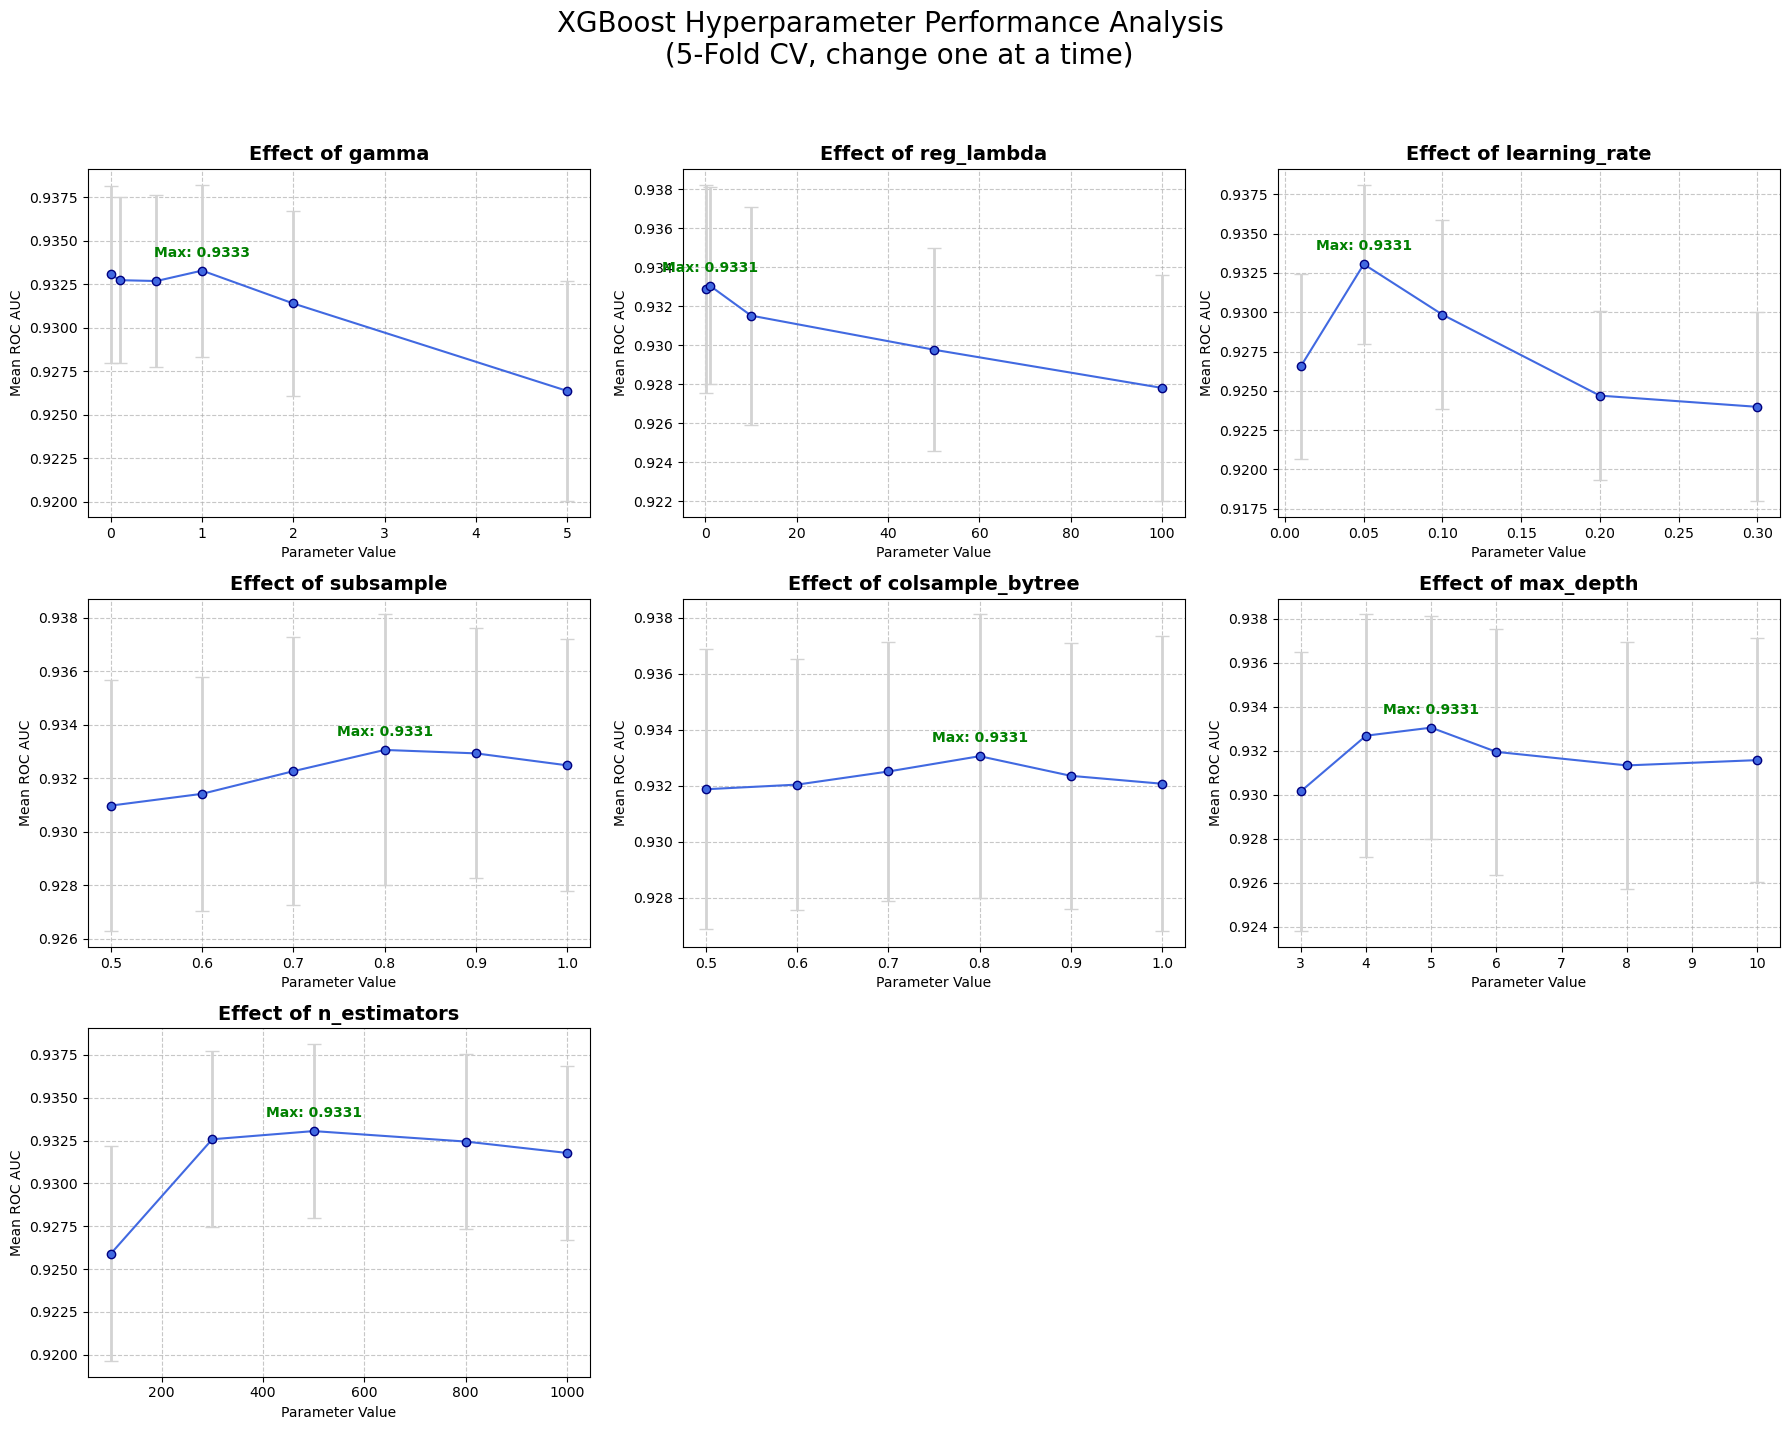

In [17]:
#PLOT RESULTS

# Calculate grid size
n_params = len(params_to_test)
n_cols = 3
n_rows = math.ceil(n_params / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows)) #fix window to fit the plots
fig.suptitle('XGBoost Hyperparameter Performance Analysis \n (5-Fold CV, change one at a time)', fontsize=20)
axes = axes.flatten() # Flatten 2D array to 1D for easy iteration

for i, (param_name, data) in enumerate(results.items()):
    ax = axes[i]

    # Extract data
    x_vals = data['values']
    y_means = data['means']
    y_errs = data['stds']

    # Plot Error Bar
    ax.errorbar(x_vals, y_means, yerr=y_errs, fmt='-o', capsize=5,
                color='royalblue', ecolor='lightgray', elinewidth=2, markeredgecolor='navy')
    # error bars are standard deviation on the hyperparameter value (each has number of folds samples)

    # Styling
    ax.set_title(f'Effect of {param_name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Parameter Value', fontsize=10)
    ax.set_ylabel('Mean ROC AUC', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.7)

    # Highlight the max value
    max_idx = np.argmax(y_means)
    ax.annotate(f'Max: {y_means[max_idx]:.4f}',
                xy=(x_vals[max_idx], y_means[max_idx]),
                xytext=(0, 10), textcoords='offset points', ha='center',
                color='green', fontweight='bold')
# delete extra axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to fit title
plt.show()

In [18]:
# TRAINING ON BEST FOUND PARAMETERS
print("FINAL ANALYSIS: COMBINING BEST PARAMETERS")

# Extract best parameters automatically from results
best_found_params = base_params.copy() # Start with base defaults

print("Best parameters found individually:")
for param_name, data in results.items():
    # Find index of maximum Mean AUC
    best_idx = np.argmax(data['means'])
    best_value = data['values'][best_idx]
    best_score = data['means'][best_idx]

    # Update the best params dictionary
    best_found_params[param_name] = best_value

    print(f"  - {param_name}: {best_value} (AUC: {best_score:.4f})")

print("\nFull configuration for final model:")
print(best_found_params)

# Train on the WHOLE dataset (Production Ready)
print("\nTraining final model on full dataset...")

final_model = xgb.XGBClassifier(**best_found_params)
final_model.fit(X_training, Y_training)


# Final Evaluation on Test Set
print("FINAL TEST SET PERFORMANCE")

# Final predictions
y_pred_grid_xgb = final_model.predict(X_test) # of grid search optimized XGB
y_prob_grid_xgb = final_model.predict_proba(X_test)[:, 1] # of grid search optimized XGB

# Calculate accuracy for more clear results
acc_grid_xgb = accuracy_score(Y_test, y_pred_grid_xgb)
zero_one_grid_xgb = 1 - acc_grid_xgb

# Final AUC score for comparison
roc_auc_grid_xgb = roc_auc_score(Y_test, y_prob_grid_xgb) # of grid search optimized XGB

print(f"Final Test ROC AUC:  {roc_auc_grid_xgb:.4f}")
print(f"Final Test Accuracy: {acc_grid_xgb:.4f}")
print(f"Final Test 0-1 Loss: {zero_one_grid_xgb:.4f} (Error Rate)")

# Number of missclassified events
n_errors = int(zero_one_grid_xgb * len(Y_test))
print(f"\nTotal misclassified samples: {n_errors} out of {len(Y_test)}")

FINAL ANALYSIS: COMBINING BEST PARAMETERS
Best parameters found individually:
  - gamma: 1 (AUC: 0.9333)
  - reg_lambda: 1 (AUC: 0.9331)
  - learning_rate: 0.05 (AUC: 0.9331)
  - subsample: 0.8 (AUC: 0.9331)
  - colsample_bytree: 0.8 (AUC: 0.9331)
  - max_depth: 5 (AUC: 0.9331)
  - n_estimators: 500 (AUC: 0.9331)

Full configuration for final model:
{'booster': 'gbtree', 'objective': 'binary:logistic', 'n_jobs': -1, 'scale_pos_weight': np.float64(0.5425317185697809), 'tree_method': 'hist', 'eval_metric': 'auc', 'verbosity': 0, 'n_estimators': 500, 'learning_rate': 0.05, 'max_depth': 5, 'subsample': 0.8, 'colsample_bytree': 0.8, 'gamma': 1, 'reg_lambda': 1}

Training final model on full dataset...
FINAL TEST SET PERFORMANCE
Final Test ROC AUC:  0.9350
Final Test Accuracy: 0.8778
Final Test 0-1 Loss: 0.1222 (Error Rate)

Total misclassified samples: 581 out of 4755


#### Performance analysis for different parameters - grid search (using Optuna)
Strategy (more encompassing): explore points in hyperparameter space in search of optimum combination. Repeat for a number of trials. Optimization is done via [_Tree structured Parzen Estimator_ (TPE) algorithm](https://arxiv.org/pdf/2304.11127), which is implemented in the "Optuna" module.

On each trial, TPE fits one Gaussian Mixture Model (GMM) $l(x)$ (_i.e._ a Kernel Density Estimate of the true probability distribution of hyperparameter values, where the basis consists of Gaussian functions) to the set of hyperparameter values associated with the best objective values; and another GMM $g(x)$ to the remaining hyperparameter values. It chooses the hyperparameter value $x$ that maximizes the ratio $\frac{l(x)}{g(x)}$. It can be proven that maximizing this ratio is (approximately) equivalent to minimizing the quantile-evidence of the model, $\int_{-\infty}^{y^{\gamma}} p(y|x,D) \, dy$ (where $D$ is a set of $x-y$ observations and $y$ an observation of the objective function). The proof relies on Bayes' theorem and on the assumption that a "better" subset of hyperhyperparameters $D^{l}$ exists such that the likelihood $p(x|y,D)$ is equal to $p(x|D^{l})$ for $y$ in the top gamma quantile of observations, $y \leq y^{\gamma}$. Note that the evaluation of the objective (or "loss") function, here, is expensive as it involves training the model with the given hyperparameters: for this reason, it would be computationally unfeasible to use a gradient descent method. Because of the algorithm relying on these successive "splits" in hyperparameter space, it is said to have a "tree-like" structure.

We use 0-1 loss as metric, as ROC-AUC is not a differentiable loss function, so it can only be used as an evaluation metric.

##### Setup

In [19]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
def objective(trial):
    param_space = {
        'booster': 'gbtree',
        'objective': 'binary:logistic',
        'n_jobs': -1,
        #'scale_pos_weight': ratio,
        'tree_method': 'hist',
        'verbosity': 0,
        'early_stopping_rounds': 50,  # added: early stopping if loss does not improve

        # Define grid search
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.001, 100, log=True),
        'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.5, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'n_estimators': trial.suggest_int('n_estimators', 100, 2000),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0.5, 2),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10)
    }


    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    for train_idx, val_idx in cv.split(X_training, Y_training):
        X_tr, X_vl = X_training[train_idx], X_training[val_idx]
        y_tr, y_vl = Y_training[train_idx], Y_training[val_idx]

        model = xgb.XGBClassifier(**param_space, random_state=42)
        model.fit(X_tr, y_tr, eval_set=[(X_vl, y_vl)], verbose=False)
        scores.append(roc_auc_score(y_vl, model.predict_proba(X_vl)[:, 1]))

    return np.mean(scores)

# Study execution
study_xgb = optuna.create_study(direction='maximize')

##### Optimization

In [20]:
i=time.time()
study_xgb.optimize(objective, n_trials=50) # ie. run TPE algo for (at most) n_trials times
f=time.time()
# Final results
print("\nBest parameters found with Optuna:")
print(study_xgb.best_params)
elapsed_xgb=f-i
print(f"Training completed in {elapsed_xgb:.1f} seconds.")


Best parameters found with Optuna:
{'gamma': 0.43033847474409176, 'reg_lambda': 1.2392167291202723, 'learning_rate': 0.052581556409402146, 'subsample': 0.7078572368459364, 'colsample_bytree': 0.8050821354682004, 'max_depth': 8, 'n_estimators': 466, 'scale_pos_weight': 1.3655943747058923, 'min_child_weight': 2}
Training completed in 32.2 seconds.


We plot the "functional ANOVA" score, _i.e._ the fraction of total variance explained by each hyperparameter, which is readily available in Optuna. We note above all the importance of learning rate.

In [21]:
#VISUALISE PARAMETER IMPORTANCE
optuna.visualization.plot_param_importances(study_xgb).show()

/opt/anaconda3/lib/python3.13/site-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.

You can however, use the Kaleido API directly which will work with your plotly version. `kaleido.write_fig(...)`, for example. Please see the kaleido documentation.




##### Train model on best hyperparameters

In [22]:
final_params_xgb = {
    'booster': 'gbtree',
    'objective': 'binary:logistic',
    'tree_method': 'hist',
    'random_state': 42,
    'early_stopping_rounds': 50,   # moved here from fit()
    'eval_metric': 'auc',          # moved here from fit()
    **study_xgb.best_params
}

best_model_xgb = xgb.XGBClassifier(**final_params_xgb)
best_model_xgb.fit(
    X_training, Y_training,
    eval_set=[(X_val, Y_val)], # will be used for early stopping (so, keep even if using CV)
    verbose=False
)

# Test set evaluation
y_pred_xgb = best_model_xgb.predict(X_test)
y_prob_xgb = best_model_xgb.predict_proba(X_test)[:, 1]

roc_auc_clean_xgb = roc_auc_score(Y_test, y_prob_xgb)
acc_clean_xgb = accuracy_score(Y_test, y_pred_xgb)
err_clean_xgb = 1 - acc_clean_xgb

print(f"ROC AUC Score: {roc_auc_clean_xgb:.4f}")
print(f"Accuracy Score: {acc_clean_xgb:.4f}")
print(f"0-1 Mean Loss: {err_clean_xgb:.4f}")

ROC AUC Score: 0.9367
Accuracy Score: 0.8835
0-1 Mean Loss: 0.1165


Similar accuracy as with one-at-a-time search

### CatBoost

We try another kind of common Gradient Boosting algorithm: "Catboost". With respect to XGBoost and other Boosting alrgorithms, and without going into too much into detail, Catboost:
* typically builds symmetric (oblivious) trees, where the same feature and split condition are used at all nodes of a given depth. XGBoost on the other hand builds asymmetric, level-wise trees, which can lead to more complex and potentially less generalizable structures
* introduces a novel approach called ["Ordered Boosting"](https://arxiv.org/pdf/1706.09516), a permutation-driven alternative designed to prevent the target leakage that can occur in standard gradient boosting algorithms
* is designed with sensible defaults and aims to require less manual tuning to achieve good performance
* can be slower to train due to its ordered boosting mechanism, but it often provides competitive or superior accuracy and is sometimes noted for faster prediction speed once trained.

The theoretical justification for this algorithm is the following. Most implementations of gradient boosting, like XGBoost and LGBoost, face the following statistical issue. A prediction model $F$ obtained after several steps of boosting relies on the targets (labels) of all training examples. This actually leads to a shift of the distribution of $F(x_k)\mid x_k$ for a training example $x_k$ from the distribution of $F(x)\mid x$ for a test example $x$. This finally leads to a _prediction shift_ of the learned model. This problem is a special kind of so-called _target leakage_, _i.e._, the use of information during model training that would not be available at prediction time.

Indeed, in most Boosted models gradients used at each step to compute the new predictor, $F_t$, are estimated using the target values of the same data points the current model $F^{t-1}$ was built on. However, the conditional distribution $F^{t-1}(x_k)\mid x_k$ for a training example $x_k$ is shifted, in general, from the distribution $F^{t-1}(x)\mid x$ for a test example $x$.

The CatBoost algorithm provides a solution to this problem (along with others, as we mentioned) by performing permutations of the training set, such that for calculating the residual on an example, we always use a model trained without it. The practical implementation is not so straightforward, but it is based on this idea.

#### Grid search (Optuna), ROC-AUC metric

The hyperparameters involved in this model are:

* `iterations`: number of boosting rounds (trees); more trees increase capacity but may overfit
*  `learning_rate`: same as XGBoost
* `depth`: same as `max_depth` for XGBoost
* `l2_leaf_reg`: same as `lambda` for XGBoost
* `random_strength`: strength of Gaussian noise added to split scores (_i.e._, the reduction in loss); acts as a regularizer by introducing randomness during tree construction
* `bootstrap_type` (Bayesian) and `bagging_temperature`: we use Bayesian bootstrap with a temperature parameter; higher temperature increases sample-weight randomness, decorrelating trees (see below)
* `colsample_bylevel`: same as `colsample_bytree` for XGBoost
* `min_data_in_leaf`: same as `min_child_weight` for XGBoost
* `scale_pos_weight`: same as for XGBoost

_Bootstrapping_ is a concept similar to subsapling, wich proved effective in practice. It assigns random weights to samples via a certain process. This is usually the heaviest part of Catboost's computation.

For Bayesian bootstrapping, each example is assigned a weight $(-\text{log}(u))^t$ where $u$ is sampled from a uniform distribution on $]0,1[$ and $t$ is the set bagging "temperature". Higher "temperature" increases weight randomness leading to more tree decorrelation, but slower training.

In [23]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
def objective(trial):
    param_space = {
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        'task_type': 'CPU',
        'verbose': False,
        'random_seed': 42,

        # Parameters to optimize
        'iterations': trial.suggest_int('iterations', 100, 1000), # or: 100, 1000
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 1.0, log=True),
        'depth': trial.suggest_int('depth', 4, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 0.01, 10.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 0.0, 10.0),

        'bootstrap_type': 'Bayesian', # or: 'Bernoulli'
        #'subsample': trial.suggest_float('subsample', 0.5, 1.5),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 5.0),

        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0.5, 1.5, log=True),

        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 3, 30)
    }


    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    for train_idx, val_idx in cv.split(X_training, Y_training):
        X_tr, X_vl = X_training[train_idx], X_training[val_idx]
        y_tr, y_vl = Y_training[train_idx], Y_training[val_idx]

        model = cb.CatBoostClassifier(**param_space)
        model.fit(X_tr, y_tr, eval_set=[(X_vl, y_vl)], early_stopping_rounds= 50, verbose=False)
        scores.append(roc_auc_score(y_vl, model.predict_proba(X_vl)[:, 1]))

    return np.mean(scores)

# Study execution
study_cb = optuna.create_study(direction='maximize')

In [24]:
i=time.time()
study_cb.optimize(objective, n_trials=50) # ie. run TPE algo for (at most) n_trials times
f=time.time()
# Final results
print("\nBest parameters found with Optuna:")
print(study_cb.best_params)
elapsed_cb=f-i
print(f"Training completed in {elapsed_cb:.1f} seconds.")


Best parameters found with Optuna:
{'iterations': 841, 'learning_rate': 0.10434035295388082, 'depth': 4, 'l2_leaf_reg': 0.1116328263220003, 'random_strength': 6.033876307523478, 'bagging_temperature': 0.22348223433025644, 'scale_pos_weight': 1.1180649963650797, 'colsample_bylevel': 0.7427896922151808, 'min_data_in_leaf': 19}
Training completed in 142.5 seconds.


In [25]:
 # Training on whole set
final_model_cb = cb.CatBoostClassifier(
    loss_function='Logloss',
    eval_metric='AUC',
    task_type='CPU',
    random_seed=42,
    verbose=False,
    **study_cb.best_params
)

final_model_cb.fit(
    X_training, Y_training,
    eval_set=[(X_val, Y_val)],
    early_stopping_rounds=50,
    verbose=False
)

# Test set evaluation
y_pred_cb = final_model_cb.predict(X_test)
y_prob_cb = final_model_cb.predict_proba(X_test)[:, 1]
roc_auc_clean_cb=roc_auc_score(Y_test, y_prob_cb)
acc_clean_cb=accuracy_score(Y_test, y_pred_cb)
err_clean_cb=1-acc_clean_cb

print(f"CATBOOST FINAL PERFORMANCE (TEST SET)")
print(f"ROC AUC:  {roc_auc_clean_cb:.4f}")
print(f"Accuracy: {acc_clean_cb:.4f}")
print(f"0-1 Loss: {err_clean_cb:.4f}")

CATBOOST FINAL PERFORMANCE (TEST SET)
ROC AUC:  0.9347
Accuracy: 0.8835
0-1 Loss: 0.1165


In [26]:
#VISUALISE PARAMETER IMPORTANCE
optuna.visualization.plot_param_importances(study_cb).show()

### LightGMB

LightGBM, short for Light Gradient-Boosting Machine, is another gradient boosting library based on decision trees. The development focus however is on performance and scalability. A features towards faster training is, for example, retaining all large‑gradient instances while randomly downsampling small‑gradient ones.

LightGBM is typically the fastest to train among major boosting libraries, and its default settings often perform well without extensive tuning.

The hyperparameters involved in this model are:

- `n_estimators`: same as `iterations` in CatBoost
- `learning_rate`: same as before
- `max_depth`: same as before
- `reg_lambda`: same as before
- `min_child_samples`: same as before
- `subsample`: same as before
- `colsample_bytree`: same as before
- `scale_pos_weight`: same as before

#### Grid search (Optuna), ROC-AUC metric

In [27]:
### LightGBM Optimisation with Optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    param_space = {
        'boosting_type': 'gbdt',
        'objective': 'binary',
        'metric': 'auc',
        'n_jobs': -1,
        'random_state': 42,
        'verbosity': -1,

        # Parameters to optimize
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 1.0, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 10.0, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 3, 50),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0.5, 10.0, log=True),

        # Fixed parameters for bagging
        'bagging_freq': 1,   # perform bagging at every iteration
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    for train_idx, val_idx in cv.split(X_training, Y_training):
        X_tr, X_vl = X_training[train_idx], X_training[val_idx]
        y_tr, y_vl = Y_training[train_idx], Y_training[val_idx]

        model = lgb.LGBMClassifier(**param_space)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_vl, y_vl)],
            eval_metric='auc',
            callbacks=[lgb.early_stopping(50)]#, lgb.log_evaluation(0)]
        )
        scores.append(roc_auc_score(y_vl, model.predict_proba(X_vl)[:, 1]))

    return np.mean(scores)

# Study execution
study_lgb = optuna.create_study(direction='maximize')

i=time.time()
study_lgb.optimize(objective, n_trials=50)
f=time.time()
elapsed_lgb=f-i
print(f"Training completed in {elapsed_lgb:.1f} seconds.")

# Final results
print("Best parameters found with Optuna:")
print(study_lgb.best_params)

# Training on whole set
final_model_lgb = lgb.LGBMClassifier(**study_lgb.best_params, random_state=42)
final_model_lgb.fit(
    X_training, Y_training,
    eval_set=[(X_val, Y_val)],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

# Test set evaluation
y_pred_lgb = final_model_lgb.predict(X_test)
y_prob_lgb = final_model_lgb.predict_proba(X_test)[:, 1]
roc_auc_clean_lgb=roc_auc_score(Y_test, y_prob_lgb)
acc_clean_lgb=accuracy_score(Y_test, y_pred_lgb)
err_clean_lgb=1-acc_clean_lgb

print(f"LIGHTGBM FINAL PERFORMANCE (TEST SET)")
print(f"ROC AUC:  {roc_auc_clean_lgb:.4f}")
print(f"Accuracy: {acc_clean_lgb:.4f}")
print(f"0-1 Loss: {err_clean_lgb:.4f}")

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[389]	valid_0's auc: 0.922404
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[275]	valid_0's auc: 0.925342
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[256]	valid_0's auc: 0.908113
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[527]	valid_0's auc: 0.924089
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[527]	valid_0's auc: 0.90699
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[133]	valid_0's auc: 0.908207
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[133]	valid_0's auc: 0.910761
Training until validation scores don't improve for 50 rounds
Did no

Best parameters found with Optuna:
{'n_estimators': 648, 'learning_rate': 0.054297553521490086, 'max_depth': 12, 'reg_lambda': 0.0111354520659252, 'min_child_samples': 4, 'subsample': 0.6123269588065194, 'colsample_bytree': 0.8340496040796322, 'scale_pos_weight': 1.5523050475722626}



LIGHTGBM FINAL PERFORMANCE (TEST SET)
ROC AUC:  0.9347
Accuracy: 0.8839
0-1 Loss: 0.1161

In [28]:
optuna.visualization.plot_param_importances(study_lgb).show()

### Conclusions

In the following plot we summarize the performance of the three tuned models.

In [29]:
models = ['RandomForest', 'GradientBoost', 'LightGBM', 'XGBoost', 'CatBoost']

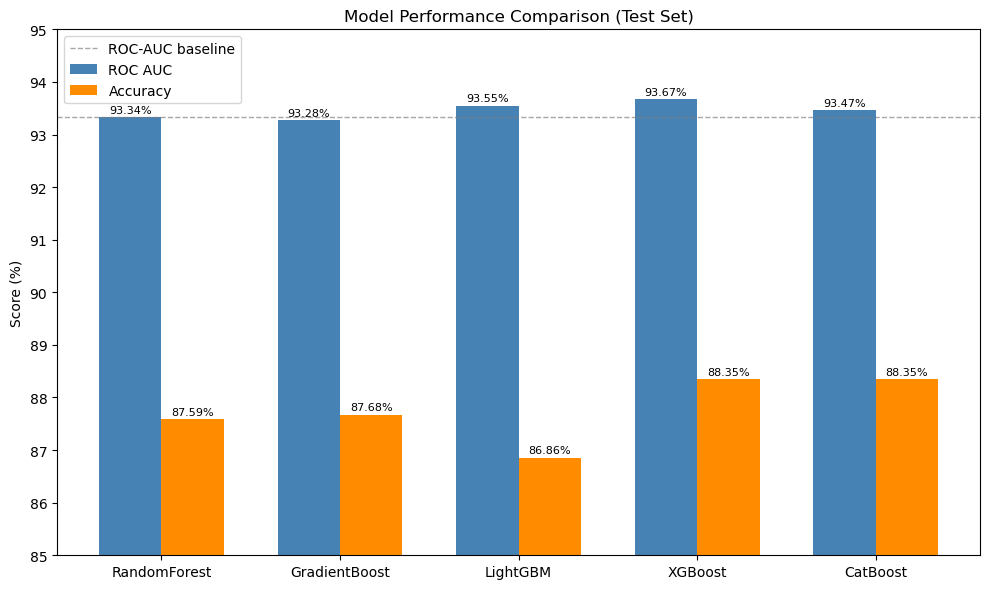

In [30]:
aucs = [100 * roc_auc_clean_rf,
        100 * roc_auc_clean_gbm,
        100 * roc_auc_clean_lgb,
        100 * roc_auc_clean_xgb,
        100 * roc_auc_clean_cb]

accs = [100 * acc_clean_rf,
        100 * acc_clean_gbm,
        100 * acc_clean_lgb,
        100 * acc_clean_xgb,
        100 * acc_clean_cb]

x = np.arange(len(models))
width = 0.35
fig, ax = plt.subplots(figsize=(10,6))
bars1 = ax.bar(x - width/2, aucs, width, label='ROC AUC', color='steelblue')
bars2 = ax.bar(x + width/2, accs, width, label='Accuracy', color='darkorange')
ax.set_ylabel('Score (%)')
ax.set_title('Model Performance Comparison (Test Set)')
ax.set_xticks(x)
ax.set_yticks(np.arange(84,96))
ax.set_xticklabels(models)
for bar in bars1 + bars2:
    h = bar.get_height()
    ax.annotate(f'{h:.2f}%', xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0,3), textcoords='offset points', ha='center', fontsize=8)
ax.set_ylim(85, 95)
ax.axhline(y=100 * roc_auc_clean_rf, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='ROC-AUC baseline')
ax.legend()
plt.tight_layout()
plt.show()

We now plot the ROC curve, the area under which coincides with the evaluation metric we used, _i.e._ the ROC-AUC. Recall that the larger the area, the better; an area of 0.5 corresponds to a random guess, and of 1 to a perfect classification. We zoom on the relevant points on this curve, _i.e._ those where the probability ofa false positive is under the threshold of 20%, as would be the case for some scientific experiments.

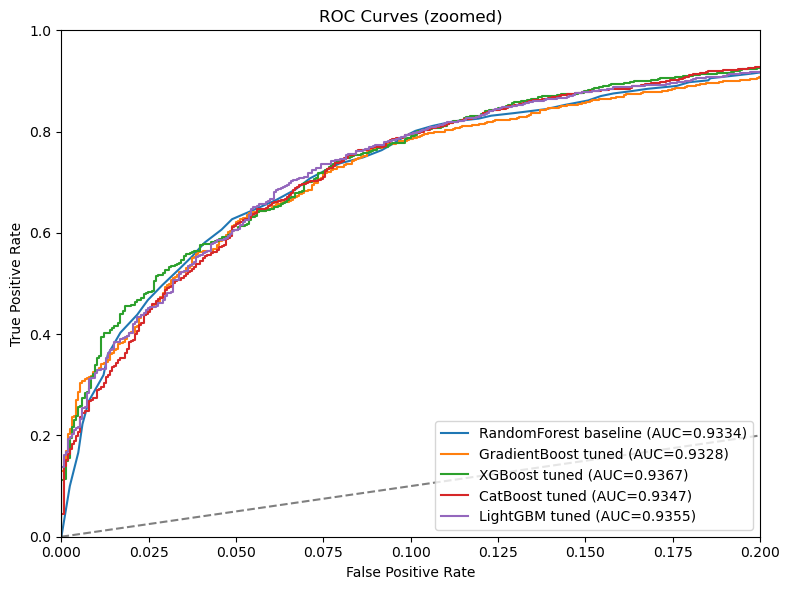

In [31]:
fig, ax = plt.subplots(figsize=(8,6))
for name, y_prob in [('RandomForest baseline', y_prob_rf),
                     ('GradientBoost tuned', y_prob_gbm),
                     ('XGBoost tuned', y_prob_xgb),
                     ('CatBoost tuned', y_prob_cb),
                     ('LightGBM tuned', y_prob_lgb)]:
    fpr, tpr, _ = roc_curve(Y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(Y_test, y_prob):.4f})') # computes it again

ax.plot([0,1],[0,1],'k--', alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves (zoomed)')
ax.set_xlim(0., 0.2)
ax.set_ylim(0, 1.0)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

We now plot Optuna's optimization history for the three models. We can observe how fluctuations in ROC-AUC metric become smaller while progressing with iterations, which indicates an effective exploration of the .

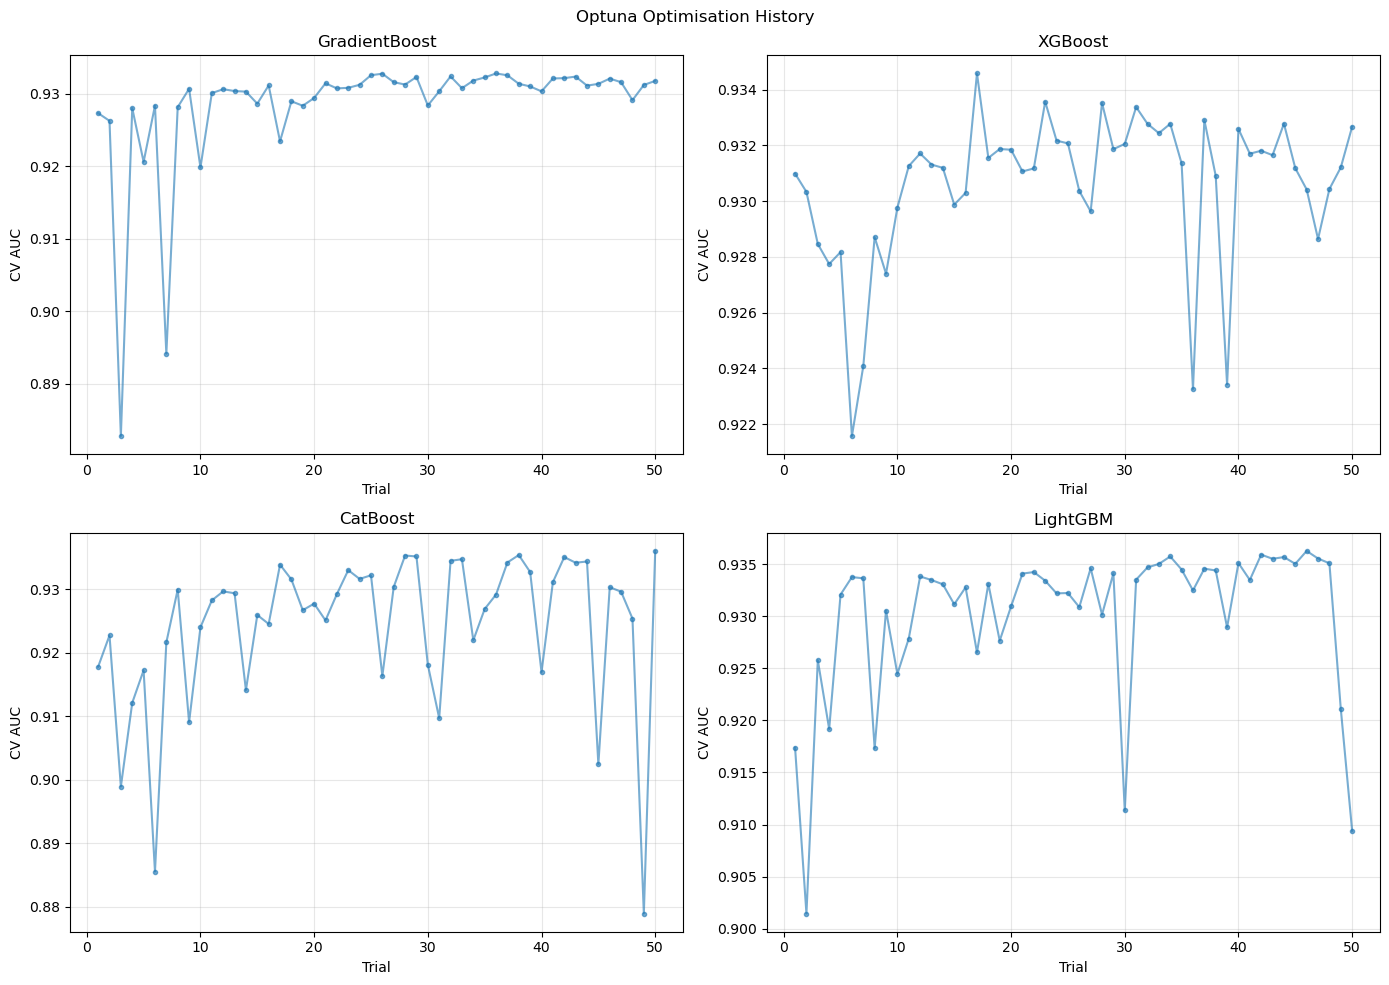

In [32]:
from optuna.visualization import plot_optimization_history

def plot_convergence(study, name, ax):
    trials = study.trials
    values = [t.value for t in trials if t.state == optuna.trial.TrialState.COMPLETE]
    ax.plot(range(1, len(values)+1), values, marker='.', alpha=0.6)
    ax.set_title(name)
    ax.set_xlabel('Trial')
    ax.set_ylabel('CV AUC')
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plot_convergence(study_gbm, 'GradientBoost', axes[0, 0])
plot_convergence(study_xgb, 'XGBoost', axes[0, 1])
plot_convergence(study_cb,  'CatBoost',    axes[1, 0])
plot_convergence(study_lgb, 'LightGBM',    axes[1, 1])
fig.suptitle('Optuna Optimisation History')
plt.tight_layout()
plt.show()

We also plot the SHAP score for the best model, _i.e._ the XGBoost tuned model.

SHAP values measure how much each feature pushes a prediction away from the average prediction. For tree models, TreeSHAP computes these by tracking how splits change the expected output as it traverses each path, averaging the feature's contribution over all trees. The result is an additive explanation where each feature's SHAP value plus the baseline equals the model's prediction for that instance. (Therefore: one point = one feature of one sample from test set, from the positive class).

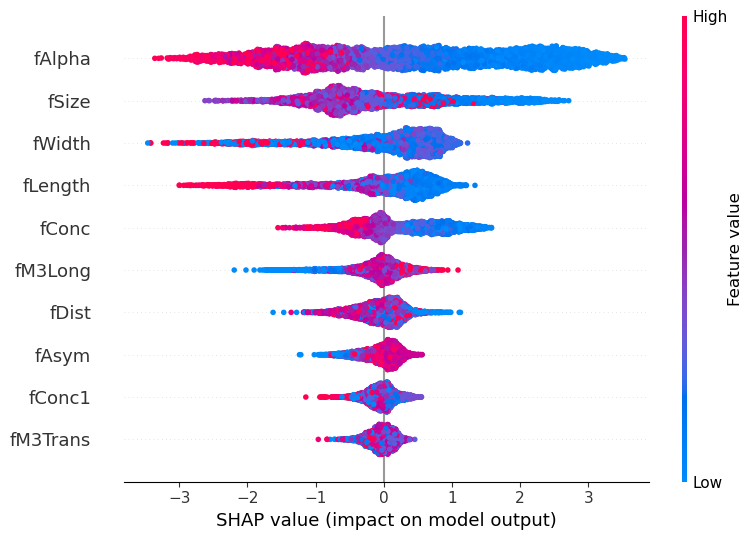

In [33]:
explainer_xgb = shap.TreeExplainer(best_model_xgb) # ie. tuned XGBoost
shap_values_xgb = explainer_xgb.shap_values(X_test)  # subsample for speed
shap.summary_plot(shap_values_xgb, X_test, feature_names=feature_names)

## Neural network comparison

In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GaussianNoise
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import AUC

#### Optuna optimisation

In [35]:
scaler = StandardScaler() # standardize input data beforehand
X_training_sc = scaler.fit_transform(X_training)
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

In [36]:
def objective_nn(trial):
    # Hyperparameters to tune
    units1 = trial.suggest_int('units1', 32, 128, step=32)
    units2 = trial.suggest_int('units2', 16, 64, step=16)
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.6)
    l2_reg = trial.suggest_float('l2_reg', 1e-6, 1e-3, log=True)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    noise_std = trial.suggest_float('noise_std', 0.0, 0.2)

    model = Sequential()
    model.add(GaussianNoise(noise_std, input_shape=(10,)))
    model.add(Dense(units1, activation='relu', kernel_regularizer=l2(l2_reg)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(units2, activation='relu', kernel_regularizer=l2(l2_reg)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=Adam(learning_rate),
        loss='binary_crossentropy',
        metrics=[AUC(curve='ROC', name='auc')]
    )

    early_stop = EarlyStopping(monitor='val_auc', mode='max', patience=10,
                               restore_best_weights=True)

    history = model.fit(
        X_training_sc, Y_training,
        validation_data=(X_val_sc, Y_val),
        epochs=200, batch_size=32, callbacks=[early_stop], verbose=0
    )

    # Return the best validation AUC achieved during training
    return max(history.history['val_auc'])

# ------------------------------------------------------------
# 2. Run the Optuna study
# ------------------------------------------------------------
study_nn = optuna.create_study(direction='maximize')
i = time.time()
study_nn.optimize(objective_nn, n_trials=30, show_progress_bar=True)
elapsed_nn_tune = time.time() - i
print(f"NN Optuna tuning completed in {elapsed_nn_tune:.1f} seconds.")
print("Best NN hyperparameters:", study_nn.best_params)

  0%|          | 0/30 [00:00<?, ?it/s]

/opt/anaconda3/lib/python3.13/site-packages/keras/src/layers/regularization/gaussian_noise.py:29: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



NN Optuna tuning completed in 309.8 seconds.
Best NN hyperparameters: {'units1': 64, 'units2': 16, 'dropout_rate': 0.17752471079230803, 'l2_reg': 5.2271906219815255e-05, 'learning_rate': 0.0016052023872692783, 'noise_std': 0.00798074727297763}


In [37]:
# IMPORTANT NOTE: was trained on basic hyperparameters: hidden_units=(64, 32),   # tuple of units per hidden layer – tune length & sizes
                #dropout_rate=0.4,
                #l2_reg=1e-4,
                #noise_std=0.02,
                #learning_rate=1e-3

best_nn_params = study_nn.best_params

def build_model(input_dim,
                units1=best_nn_params['units1'],
                units2=best_nn_params['units2'],
                dropout_rate=best_nn_params['dropout_rate'],
                l2_reg=best_nn_params['l2_reg'],
                noise_std=best_nn_params['noise_std'],
                learning_rate=best_nn_params['learning_rate']):

    model = Sequential()
    model.add(GaussianNoise(noise_std, input_shape=(input_dim,)))
    model.add(Dense(units1, activation='relu', kernel_regularizer=l2(l2_reg)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(units2, activation='relu', kernel_regularizer=l2(l2_reg)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=Adam(learning_rate),
        loss='binary_crossentropy',
        metrics=[AUC(curve='ROC', name='auc')] # AUC class with curve parameter
    )
    return model

In [38]:
X_training.shape

(10699, 10)

In [39]:
simple_nn=build_model(input_dim=10)

In [40]:
simple_nn.summary()

Model: "sequential_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gaussian_noise_30               │ (None, 10)             │             0 │
│ (GaussianNoise)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_90 (Dense)                │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_60          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_60 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_91 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_61          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_61 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_92 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,081 (8.13 KB)

 Trainable params: 1,921 (7.50 KB)

 Non-trainable params: 160 (640.00 B)

In [41]:
#dense, dropout, dense, dropout, dense

In [42]:
early_stop = EarlyStopping(
    monitor='val_auc', #AUC(curve='ROC'),
    mode='max',
    patience=10,
    restore_best_weights=True
)

In [43]:
i=time.time()
history = simple_nn.fit(
    X_training_sc, Y_training,
    validation_data=(X_val_sc, Y_val),
    epochs=200, # but early stopping
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)
f=time.time()
elapsed_nn=f-i
print(f"Training completed in {elapsed_nn:.1f} seconds.")

Training completed in 11.6 seconds.


In [44]:
test_loss, test_auc = simple_nn.evaluate(X_test_sc, Y_test, verbose=0)
print(f"\nTest ROC AUC: {test_auc:.4f}")


Test ROC AUC: 0.9321


### Robustness of tuned boosted models to worse training datasets

#### Reduced-size dataset

In [45]:
# --- Learning Curve: Test ROC‑AUC vs Training Set Size ---
# Uses tuned Optuna params for XGBoost, CatBoost, LightGBM

# Best params from  Optuna studies (hardcoded for reproducibility)
xgb_best = {
    'booster': 'gbtree', 'objective': 'binary:logistic', 'n_jobs': -1,
    'tree_method': 'hist', 'random_state': 42, 'eval_metric': 'auc',
    'early_stopping_rounds': 50, 'verbosity': 0,
    **study_xgb.best_params
}
cat_best = {
    'loss_function': 'Logloss', 'eval_metric': 'AUC', 'task_type': 'CPU',
    'verbose': False, 'random_seed': 42, 'early_stopping_rounds': 50,
    **study_cb.best_params
}
lgb_best = {
    'boosting_type': 'gbdt', 'objective': 'binary', 'metric': 'auc',
    'n_jobs': -1, 'random_state': 42, 'verbosity': -1,
    'bagging_freq': 1,
    **study_lgb.best_params
}

In [46]:
# Fractions of the training set to use
fracs = np.linspace(0.1, 0.9, 9)

In [47]:
auc_xgb, auc_cat, auc_lgb, auc_nn = [], [], [], []
i=time.time()

for frac in fracs:
    # Subsample the training data (stratified)
    X_sub, _, y_sub, _ = train_test_split(
        X_training, Y_training, train_size=float(frac), stratify=Y_training, random_state=42
    )
    # Further split off a validation subset (10%) for early stopping
    X_tr, X_val_sub, y_tr, y_val_sub = train_test_split(
        X_sub, y_sub, test_size=0.1, stratify=y_sub, random_state=42
    )

    # XGBoost
    model_xgb = xgb.XGBClassifier(**xgb_best)
    model_xgb.fit(X_tr, y_tr, eval_set=[(X_val_sub, y_val_sub)], verbose=False)
    auc_xgb.append(roc_auc_score(Y_test, model_xgb.predict_proba(X_test)[:, 1]))

    # CatBoost
    model_cat = cb.CatBoostClassifier(**{k:v for k,v in cat_best.items() if k != 'early_stopping_rounds'})  # clean up
    model_cat.fit(X_tr, y_tr, eval_set=[(X_val_sub, y_val_sub)], early_stopping_rounds=50, verbose=False)
    auc_cat.append(roc_auc_score(Y_test, model_cat.predict_proba(X_test)[:, 1]))

    # LightGBM
    model_lgb = lgb.LGBMClassifier(**lgb_best)
    model_lgb.fit(X_tr, y_tr, eval_set=[(X_val_sub, y_val_sub)],
                  callbacks=[lgb.early_stopping(50, verbose=False)])
    auc_lgb.append(roc_auc_score(Y_test, model_lgb.predict_proba(X_test)[:, 1]))

    # Scale data for NN
    scaler_nn = StandardScaler()
    X_tr_sc = scaler_nn.fit_transform(X_tr)
    X_val_sub_sc = scaler_nn.transform(X_val_sub)
    X_test_sc_lc = scaler_nn.transform(X_test)   # re‑scale test with this fraction's scaler

    m1=time.time()
    partial_elapsed_1=m1-i
    print(f"Reduced dataset level {frac} completed in {partial_elapsed_1:.1f} seconds for boosted models - now doing NN for this level")

    # Build fresh NN
    model_nn = build_model(input_dim=X_tr.shape[1])
    early_stop = EarlyStopping(monitor='val_auc', mode='max', patience=10, restore_best_weights=True)

    model_nn.fit(X_tr_sc, y_tr, validation_data=(X_val_sub_sc, y_val_sub),
                 epochs=200, batch_size=32, callbacks=[early_stop], verbose=0)

    auc_nn.append(roc_auc_score(Y_test, model_nn.predict(X_test_sc_lc).ravel()))#[:, 1]))
    m=time.time()
    partial_elapsed=m-i
    print(f"Reduced dataset level {frac} completed in {partial_elapsed:.1f} seconds")

f=time.time()
elapsed_red=f-i
print(f"Reduced dataset experiment completed in {elapsed_red:.1f} seconds.")

# Save learning curve results before noise loops overwrite auc_xgb etc.
lc_auc_xgb = auc_xgb.copy()
lc_auc_cat = auc_cat.copy()
lc_auc_lgb = auc_lgb.copy()
lc_auc_nn  = auc_nn.copy()

Reduced dataset level 0.1 completed in 0.2 seconds for boosted models - now doing NN for this level


/opt/anaconda3/lib/python3.13/site-packages/keras/src/layers/regularization/gaussian_noise.py:29: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 352us/step
Reduced dataset level 0.1 completed in 1.9 seconds
Reduced dataset level 0.2 completed in 2.4 seconds for boosted models - now doing NN for this level


/opt/anaconda3/lib/python3.13/site-packages/keras/src/layers/regularization/gaussian_noise.py:29: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 371us/step
Reduced dataset level 0.2 completed in 5.4 seconds
Reduced dataset level 0.30000000000000004 completed in 5.8 seconds for boosted models - now doing NN for this level


...

149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 342us/step
Reduced dataset level 0.7000000000000001 completed in 30.7 seconds
Reduced dataset level 0.8 completed in 32.0 seconds for boosted models - now doing NN for this level


/opt/anaconda3/lib/python3.13/site-packages/keras/src/layers/regularization/gaussian_noise.py:29: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 349us/step
Reduced dataset level 0.8 completed in 36.2 seconds
Reduced dataset level 0.9 completed in 37.6 seconds for boosted models - now doing NN for this level


/opt/anaconda3/lib/python3.13/site-packages/keras/src/layers/regularization/gaussian_noise.py:29: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 350us/step
Reduced dataset level 0.9 completed in 42.3 seconds
Reduced dataset experiment completed in 42.3 seconds.


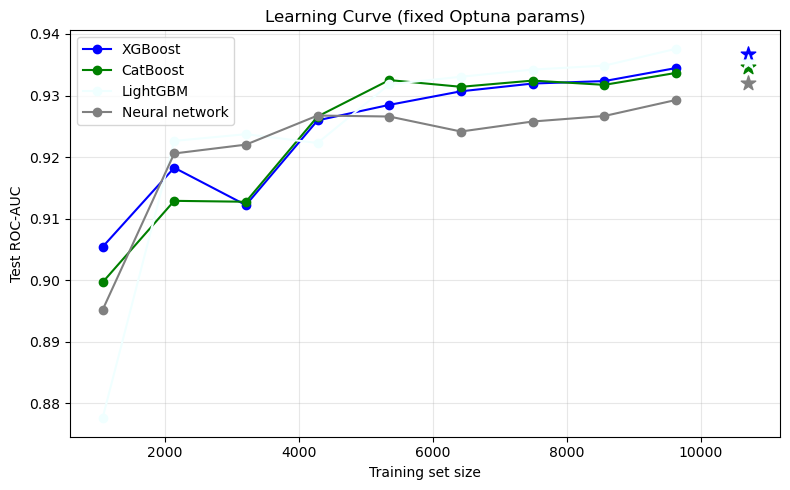

In [48]:
# Plot
train_sizes = [int(frac * len(Y_training)) for frac in fracs]
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, auc_xgb, 'o-', label='XGBoost', color='blue')
plt.plot(train_sizes, auc_cat, 'o-', label='CatBoost', color='green')
plt.plot(train_sizes, auc_lgb, 'o-', label='LightGBM', color='azure')
plt.plot(train_sizes, auc_nn, 'o-', label='Neural network', color='gray')
full_size = len(Y_training)
plt.scatter(full_size, roc_auc_clean_xgb, color='blue',   marker='*', s=120, zorder=5)
plt.scatter(full_size, roc_auc_clean_cb,  color='green',  marker='*', s=120, zorder=5)
plt.scatter(full_size, roc_auc_clean_lgb, color='azure', marker='*', s=120, zorder=5)
plt.scatter(full_size, test_auc,          color='gray', marker='*', s=120, zorder=5)   # NN
# dummy scatter for legend
#plt.scatter([], [], color='gray', marker='*', s=80, label='Full training set')
plt.xlabel('Training set size')
plt.ylabel('Test ROC‑AUC')
plt.title('Learning Curve (fixed Optuna params)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Noisy dataset

In [49]:
# ---- Robustness to Gaussian feature noise ----
def rigorous_augmentation(X, y, noise_level=0.01, multiplier=2):
    """Add Gaussian noise (scaled by feature std) and optionally multiply the dataset."""
    X_augmented_list = [X]
    y_augmented_list = [y]
    stds = np.std(X, axis=0)
    for _ in range(multiplier - 1):
        noise = np.random.normal(0, stds * noise_level, size=X.shape)
        X_noisy = X + noise
        X_augmented_list.append(X_noisy)
        y_augmented_list.append(y)
    return np.vstack(X_augmented_list), np.concatenate(y_augmented_list)

In [50]:
# todo: train also on ever lower noise levels (use log scale?) and adjusting final plot - careful not to overwrite dumped joblib variable!

In [51]:
noise_levels = np.linspace(0.1, 1., 10)
auc_drop_xgb, auc_drop_cb, auc_drop_lgb, auc_drop_nn = [], [], [], []

# Clean baselines (already computed earlier in the notebook)
clean_auc_xgb = roc_auc_clean_xgb
clean_auc_cb  = roc_auc_clean_cb
clean_auc_lgb = roc_auc_clean_lgb

i=time.time()
for p in noise_levels:
    X_aug, y_aug = rigorous_augmentation(X_training, Y_training, noise_level=p)

    # XGBoost
    m_xgb = xgb.XGBClassifier(**xgb_best)
    m_xgb.fit(X_aug, y_aug, eval_set=[(X_val, Y_val)], verbose=False)
    auc_xgb_noise = roc_auc_score(Y_test, m_xgb.predict_proba(X_test)[:, 1])
    auc_drop_xgb.append(clean_auc_xgb - auc_xgb_noise)

    # CatBoost (early_stopping_rounds belongs to fit, not constructor)
    cat_params_clean = {k: v for k, v in cat_best.items() if k != 'early_stopping_rounds'}
    m_cb = cb.CatBoostClassifier(**cat_params_clean)
    m_cb.fit(X_aug, y_aug, eval_set=[(X_val, Y_val)],
             early_stopping_rounds=50, verbose=False)
    auc_cb = roc_auc_score(Y_test, m_cb.predict_proba(X_test)[:, 1])
    auc_drop_cb.append(clean_auc_cb - auc_cb)

    # LightGBM
    m_lgb = lgb.LGBMClassifier(**lgb_best)
    m_lgb.fit(X_aug, y_aug, eval_set=[(X_val, Y_val)],
              callbacks=[lgb.early_stopping(50, verbose=False)])
    auc_lgb = roc_auc_score(Y_test, m_lgb.predict_proba(X_test)[:, 1])
    auc_drop_lgb.append(clean_auc_lgb - auc_lgb)

    m1=time.time()
    partial_elapsed_1=m1-i
    print(f"Noise level {p:.2f} completed in {partial_elapsed_1:.1f} seconds for boosted models - now doing NN for this level")

    # Neural network (fresh model each time)
    # Scale the augmented training data and the original test set
    scaler_noise = StandardScaler()
    X_aug_sc = scaler_noise.fit_transform(X_aug) # train on noisy dataset
    X_test_sc_lc = scaler_noise.transform(X_test) # test on clean dataset
    X_val_sc_nn = scaler_noise.transform(X_val) # validate (ie. early stopping) during training on clean dataset - standard practice

    nn_model = build_model(input_dim=10)   # creates a new compiled model
    early_stop = EarlyStopping(monitor='val_auc', mode='max', patience=10,
                               restore_best_weights=True)
    nn_model.fit(X_aug_sc, y_aug,
                 validation_data=(X_val_sc_nn, Y_val),
                 epochs=200, batch_size=32, callbacks=[early_stop], verbose=0)
    auc_nn = nn_model.evaluate(X_test_sc_lc, Y_test, verbose=0)[1]   # returns [loss, auc]
    # We need the clean NN AUC baseline from the original training (already computed as test_auc)
    clean_auc_nn = test_auc   # from the earlier cell where we trained on clean data
    auc_drop_nn.append(clean_auc_nn - auc_nn)

    m=time.time()
    elapsed_partial=m-i
    print(f"Noise level {p:.2f} completed after {elapsed_partial:.1f} seconds")
f=time.time()
elapsed_feat=f-i
print(f"Feature‑noise robustness experiment finished in {elapsed_feat:.1f} seconds.")

Noise level 0.10 completed in 2.5 seconds for boosted models - now doing NN for this level


/opt/anaconda3/lib/python3.13/site-packages/keras/src/layers/regularization/gaussian_noise.py:29: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Noise level 0.10 completed after 13.5 seconds
Noise level 0.20 completed in 16.0 seconds for boosted models - now doing NN for this level


/opt/anaconda3/lib/python3.13/site-packages/keras/src/layers/regularization/gaussian_noise.py:29: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Noise level 0.20 completed after 24.9 seconds
Noise level 0.30 completed in 27.8 seconds for boosted models - now doing NN for this level


...

Noise level 0.80 completed after 114.9 seconds
Noise level 0.90 completed in 117.7 seconds for boosted models - now doing NN for this level


/opt/anaconda3/lib/python3.13/site-packages/keras/src/layers/regularization/gaussian_noise.py:29: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Noise level 0.90 completed after 132.2 seconds
Noise level 1.00 completed in 135.1 seconds for boosted models - now doing NN for this level


/opt/anaconda3/lib/python3.13/site-packages/keras/src/layers/regularization/gaussian_noise.py:29: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Noise level 1.00 completed after 149.0 seconds
Feature‑noise robustness experiment finished in 149.0 seconds.


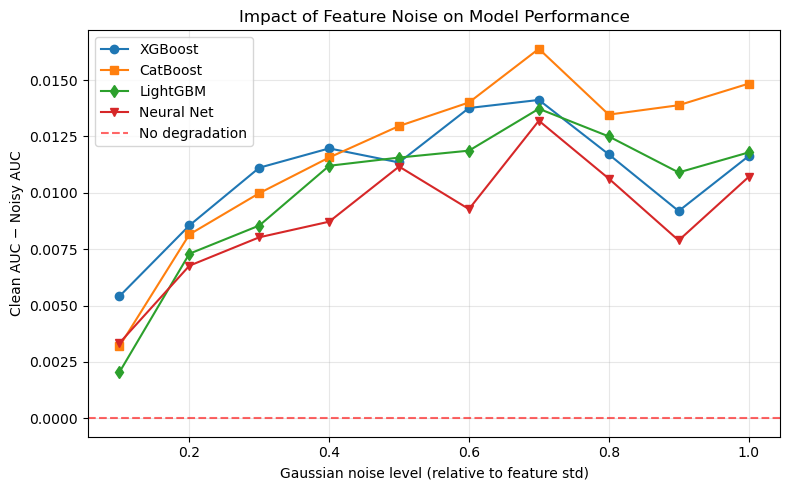

In [52]:
# Plot AUC degradation

plt.figure(figsize=(8, 5))
plt.plot(noise_levels, auc_drop_xgb, 'o-', label='XGBoost')
plt.plot(noise_levels, auc_drop_cb, 's-', label='CatBoost')
plt.plot(noise_levels, auc_drop_lgb, 'd-', label='LightGBM')
plt.plot(noise_levels, auc_drop_nn, 'v-', label='Neural Net')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.6, label='No degradation')
plt.xlabel('Gaussian noise level (relative to feature std)')
plt.ylabel('Clean AUC − Noisy AUC')
plt.title('Impact of Feature Noise on Model Performance')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Noisy labels

In [53]:
# todo: train also on ever lower noise levels (use log scale?) and adjusting final plot - careful not to overwrite dumped joblib variable!

In [54]:
gbm_best = {**study_gbm.best_params} # no early_stopping_rounds here (handled by fit)

In [55]:
# ---- Robustness to label noise (flipped labels) ----

def inject_label_noise(y, noise_level=0.1):
    """Randomly flip a fraction of labels to the opposite class."""
    y_noisy = np.array(y).copy()
    n_samples = len(y_noisy)
    n_to_flip = int(noise_level * n_samples)
    indices_to_flip = np.random.choice(n_samples, n_to_flip, replace=False)
    unique_classes = np.unique(y_noisy)
    for idx in indices_to_flip:
        original_label = y_noisy[idx]
        possible_labels = [c for c in unique_classes if c != original_label]
        y_noisy[idx] = np.random.choice(possible_labels)
    return y_noisy

noise_levels_feat = noise_levels.copy()
noise_levels = np.linspace(0, 0.2, 10)

auc_drop_xgb_feat = auc_drop_xgb.copy()
auc_drop_cb_feat  = auc_drop_cb.copy()
auc_drop_lgb_feat = auc_drop_lgb.copy()
auc_drop_nn_feat  = auc_drop_nn.copy()


auc_drop_xgb, auc_drop_cb, auc_drop_lgb, auc_drop_nn = [], [], [], []

# clean baselines (already computed earlier in the notebook)
clean_auc_xgb = roc_auc_clean_xgb
clean_auc_cb  = roc_auc_clean_cb
clean_auc_lgb = roc_auc_clean_lgb
clean_auc_nn  = test_auc

i=time.time()
for p in noise_levels:
    y_noisy = inject_label_noise(Y_training, noise_level=p)

    # XGBoost
    m_xgb = xgb.XGBClassifier(**xgb_best)
    m_xgb.fit(X_training, y_noisy, eval_set=[(X_val, Y_val)], verbose=False)
    auc_xgb = roc_auc_score(Y_test, m_xgb.predict_proba(X_test)[:, 1])
    auc_drop_xgb.append(clean_auc_xgb - auc_xgb)

    # CatBoost (early_stopping_rounds in fit, remove from params if present)
    cat_params_clean = {k: v for k, v in cat_best.items() if k != 'early_stopping_rounds'}
    m_cb = cb.CatBoostClassifier(**cat_params_clean)
    m_cb.fit(X_training, y_noisy, eval_set=[(X_val, Y_val)],
             early_stopping_rounds=50, verbose=False)
    auc_cb = roc_auc_score(Y_test, m_cb.predict_proba(X_test)[:, 1])
    auc_drop_cb.append(clean_auc_cb - auc_cb)

    # LightGBM
    m_lgb = lgb.LGBMClassifier(**lgb_best)
    m_lgb.fit(X_training, y_noisy, eval_set=[(X_val, Y_val)],
              callbacks=[lgb.early_stopping(50, verbose=False)])
    auc_lgb = roc_auc_score(Y_test, m_lgb.predict_proba(X_test)[:, 1])
    auc_drop_lgb.append(clean_auc_lgb - auc_lgb)

    m1=time.time()
    partial_elapsed_1=m1-i
    print(f"Noise level {p:.2f} completed in {partial_elapsed_1:.1f} seconds for boosted models - now doing NN for this level")

    # Neural network (re‑train from scratch on noisy labels)
    nn_model = build_model(input_dim=10)
    early_stop = EarlyStopping(monitor='val_auc', mode='max', patience=10,
                               restore_best_weights=True)
    nn_model.fit(X_training_sc, y_noisy,
                 validation_data=(X_val_sc, Y_val),
                 epochs=200, batch_size=32, callbacks=[early_stop], verbose=0) # train on noisy labels
    auc_nn = nn_model.evaluate(X_test_sc, Y_test, verbose=0)[1]
    auc_drop_nn.append(clean_auc_nn - auc_nn)

    m=time.time()
    elapsed_partial=m-i
    print(f"Label noise {p:.2f} completed after {elapsed_partial:.1f} seconds")


f=time.time()
elapsed_lab=f-i
print(f"Label‑noise robustness experiment finished in {elapsed_lab:.1f} seconds.")

Noise level 0.00 completed in 1.9 seconds for boosted models - now doing NN for this level


/opt/anaconda3/lib/python3.13/site-packages/keras/src/layers/regularization/gaussian_noise.py:29: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Label noise 0.00 completed after 12.9 seconds
Noise level 0.02 completed in 15.0 seconds for boosted models - now doing NN for this level


/opt/anaconda3/lib/python3.13/site-packages/keras/src/layers/regularization/gaussian_noise.py:29: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Label noise 0.02 completed after 21.4 seconds
Noise level 0.04 completed in 22.8 seconds for boosted models - now doing NN for this level


...

Label noise 0.16 completed after 84.7 seconds
Noise level 0.18 completed in 85.6 seconds for boosted models - now doing NN for this level


/opt/anaconda3/lib/python3.13/site-packages/keras/src/layers/regularization/gaussian_noise.py:29: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Label noise 0.18 completed after 95.6 seconds
Noise level 0.20 completed in 96.3 seconds for boosted models - now doing NN for this level


/opt/anaconda3/lib/python3.13/site-packages/keras/src/layers/regularization/gaussian_noise.py:29: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Label noise 0.20 completed after 101.7 seconds
Label‑noise robustness experiment finished in 101.7 seconds.


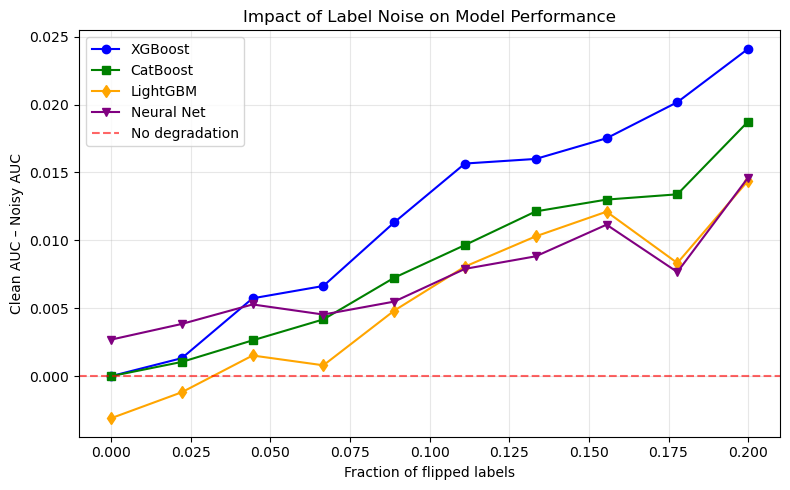

In [56]:
# Plot AUC drop
plt.figure(figsize=(8, 5))
plt.plot(noise_levels, auc_drop_xgb, 'o-', label='XGBoost', color='blue')
plt.plot(noise_levels, auc_drop_cb, 's-', label='CatBoost', color='green')
plt.plot(noise_levels, auc_drop_lgb, 'd-', label='LightGBM', color='orange')
plt.plot(noise_levels, auc_drop_nn, 'v-', label='Neural Net', color='purple')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.6, label='No degradation')
plt.xlabel('Fraction of flipped labels')
plt.ylabel('Clean AUC – Noisy AUC')
plt.title('Impact of Label Noise on Model Performance')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Other model comparisons

#### Confusion matrices

149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 326us/step


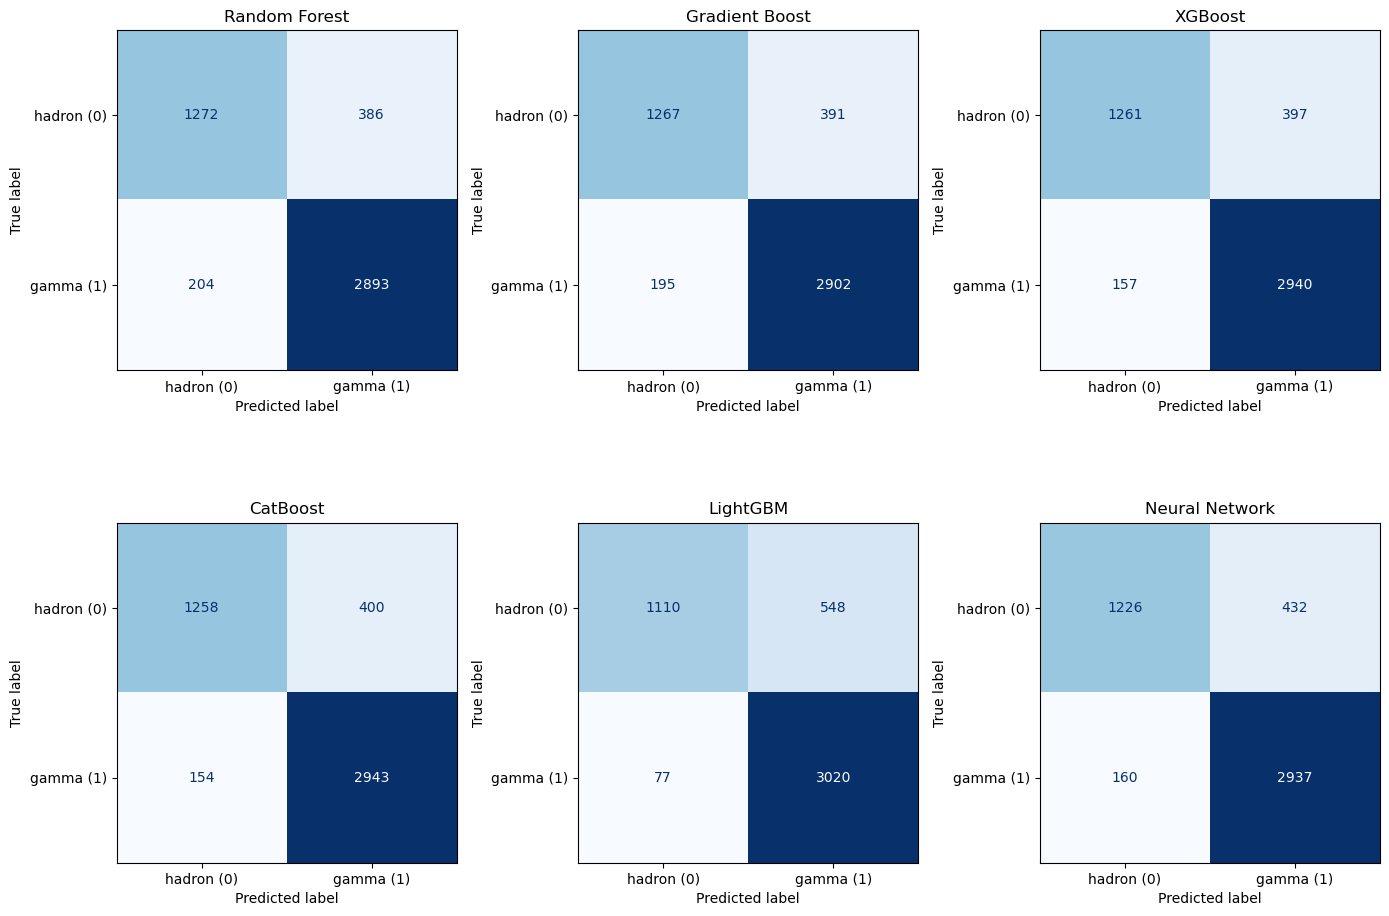

In [57]:
# Confusion matrices for all models
from sklearn.metrics import ConfusionMatrixDisplay

# NN predictions (binary)
y_pred_nn = (simple_nn.predict(X_test_sc) > 0.5).astype(int).ravel()

models_cm = [
    ('Random Forest', y_pred_rf),
    ('Gradient Boost', y_pred_gbm),
    ('XGBoost', y_pred_xgb),
    ('CatBoost', y_pred_cb),
    ('LightGBM', y_pred_lgb),
    ('Neural Network', y_pred_nn)
]

fig, axes = plt.subplots(2, 3, figsize=(14, 10))
axes = axes.flatten()

for ax, (name, y_pred) in zip(axes, models_cm):
    cm = confusion_matrix(Y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['hadron (0)','gamma (1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)

plt.tight_layout()
plt.show()

### Feature importance analysis

#### Model comparison - SHAP values

In [58]:
# 1. Random Forest (TreeExplainer)
explainer_rf = shap.TreeExplainer(rf)
shap_values_rf = explainer_rf.shap_values(X_test)[:, :, 1]  # class 1 (positive)
mean_abs_shap_rf = np.abs(shap_values_rf).mean(axis=0)

# 2. XGBoost (already computed earlier, but recompute for consistency)
explainer_xgb = shap.TreeExplainer(best_model_xgb)
shap_values_xgb = explainer_xgb.shap_values(X_test)
mean_abs_shap_xgb = np.abs(shap_values_xgb).mean(axis=0)

# 3. CatBoost (TreeExplainer works)
explainer_cb = shap.TreeExplainer(final_model_cb)
shap_values_cb = explainer_cb.shap_values(X_test)  # CatBoost returns list for classes
mean_abs_shap_cb = np.abs(shap_values_cb).mean(axis=0)

# Use a small background sample for DeepExplainer (NN)
background_nn = X_training_sc[:100]


In [59]:
# 4. Neural Network (DeepExplainer)
# Need to ensure model is in train mode? DeepExplainer uses background.
explainer_nn = shap.DeepExplainer(simple_nn, background_nn)
shap_values_nn = explainer_nn.shap_values(X_test_sc[:200])[:, :, 0]  # (200, 10)  # use subset for speed
# shap_values_nn is a list for binary: [negative_shap, positive_shap]
mean_abs_shap_nn = np.abs(shap_values_nn).mean(axis=0)   # class 1

# Collect into DataFrame
shap_importance_df = pd.DataFrame({
    'RandomForest': mean_abs_shap_rf,
    'XGBoost': mean_abs_shap_xgb,
    'CatBoost': mean_abs_shap_cb,
    'NeuralNet': mean_abs_shap_nn
}, index=feature_names)

# Optional: normalise each column to sum to 1
shap_importance_norm = shap_importance_df.div(shap_importance_df.sum(axis=0), axis=1)

/opt/anaconda3/lib/python3.13/site-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning:

Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.

/opt/anaconda3/lib/python3.13/site-packages/keras/src/models/functional.py:241: UserWarning:

The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_1110
Received: inputs=['Tensor(shape=(100, 10))']

/opt/anaconda3/lib/python3.13/site-packages/keras/src/models/functional.py:241: UserWarning:

The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_1110
Received: inputs=['Tensor(shape=(200, 10))']



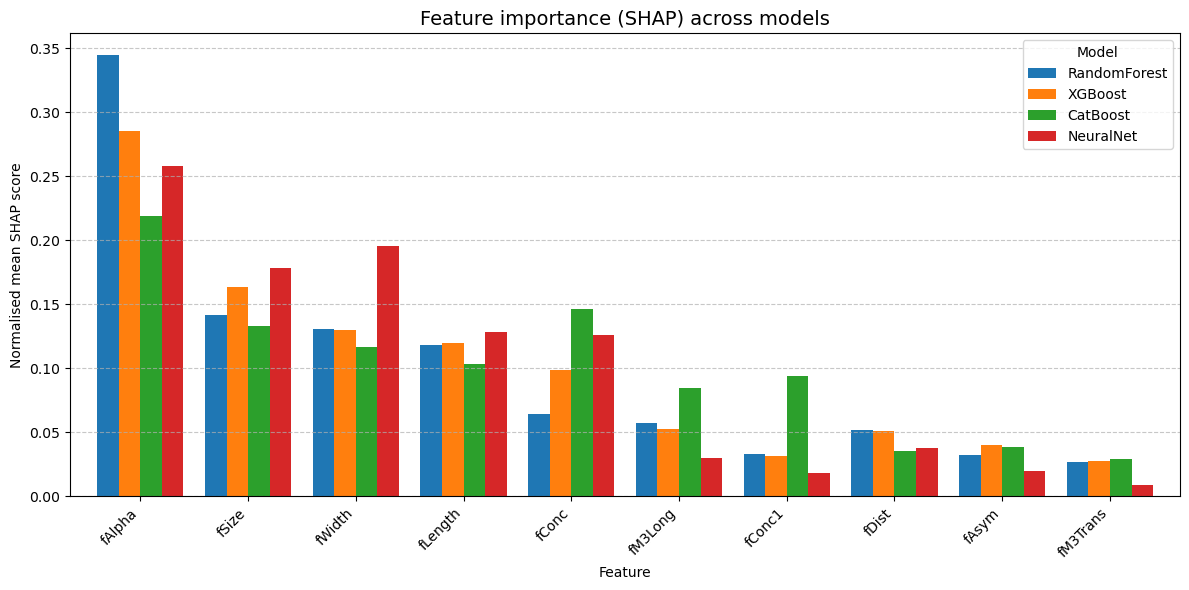

In [60]:
row_means = shap_importance_norm.mean(axis=1)
shap_importance_norm_sorted = shap_importance_norm.loc[row_means.sort_values().index][::-1]

fig, ax = plt.subplots(figsize=(12, 6))
shap_importance_norm_sorted.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Feature importance (SHAP) across models', fontsize=14)
ax.set_ylabel('Normalised mean SHAP score')
ax.set_xlabel('Feature')
ax.set_xticklabels(shap_importance_norm_sorted.index, rotation=45, ha='right')
ax.legend(title='Model')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Performance on fewer-features datasets (XGBoost only)

In [66]:
import time
import joblib
import numpy as np
from sklearn.metrics import roc_auc_score
from tensorflow.keras.callbacks import EarlyStopping

# ---- Robustness to feature elimination: XGBoost, RF, CatBoost, NN ----

models_fe = {
    'XGBoost': (best_model_xgb, mean_abs_shap_xgb, 'xgb'),
    'RandomForest': (rf, mean_abs_shap_rf, 'rf'),
    'CatBoost': (final_model_cb, mean_abs_shap_cb, 'cb'),
}
colors = {'XGBoost': 'blue', 'RandomForest': 'green', 'CatBoost': 'orange', 'NeuralNet': 'purple'}

results_fe = {}
i = time.time()

max_drop = 5
# FIX 1: Explicitly define the x-axis list for the plots
n_dropped_list = list(range(max_drop + 1)) 

for model_name, (model_obj, shap_vals, _) in models_fe.items():
    importance_order_m = np.argsort(shap_vals)
    aucs = [roc_auc_score(Y_test, model_obj.predict_proba(X_test)[:, 1])]
    for n_drop in range(1, max_drop + 1):
        keep_mask = np.ones(len(feature_names), dtype=bool)
        keep_mask[importance_order_m[:n_drop]] = False
        X_train_sub = X_training[:, keep_mask]
        X_val_sub   = X_val[:, keep_mask]
        X_test_sub  = X_test[:, keep_mask]
        
        m = model_obj.__class__(**model_obj.get_params())
        if model_name == 'XGBoost':
            m.fit(X_train_sub, Y_training, eval_set=[(X_val_sub, Y_val)], verbose=False)
        elif model_name == 'CatBoost':
            m.fit(X_train_sub, Y_training, eval_set=[(X_val_sub, Y_val)],
                  early_stopping_rounds=50, verbose=False)
        else:
            m.fit(X_train_sub, Y_training)
            
        aucs.append(roc_auc_score(Y_test, m.predict_proba(X_test_sub)[:, 1]))
        
    results_fe[model_name] = aucs
    print(f"{model_name} done after {(time.time()-i):.1f} seconds")

# Neural network
importance_order_nn = np.argsort(mean_abs_shap_nn)
aucs_nn = [roc_auc_score(Y_test, simple_nn.predict(X_test_sc).ravel())]

for n_drop in range(1, max_drop + 1):
    keep_mask = np.ones(len(feature_names), dtype=bool)
    keep_mask[importance_order_nn[:n_drop]] = False
    X_train_sub = X_training_sc[:, keep_mask]
    X_val_sub   = X_val_sc[:, keep_mask]
    X_test_sub  = X_test_sc[:, keep_mask]
    
    m_nn = build_model(input_dim=keep_mask.sum())
    es = EarlyStopping(monitor='val_auc', mode='max', patience=10, restore_best_weights=True)
    m_nn.fit(X_train_sub, Y_training, validation_data=(X_val_sub, Y_val),
             epochs=200, batch_size=32, callbacks=[es], verbose=0)
    aucs_nn.append(roc_auc_score(Y_test, m_nn.predict(X_test_sub).ravel()))
    
results_fe['NeuralNet'] = aucs_nn
f = time.time()
elapsed_feats_el = f - i
print(f"NeuralNet done. Total: {elapsed_feats_el:.1f}s")

# FIX 2: Save the data immediately so you don't have to rely on the cell at the bottom of the notebook
joblib.dump({
    'n_dropped_list': n_dropped_list,
    'results_fe': results_fe,
}, 'feature_elimination_results.pkl')

print("\n✅ SUCCESS: feature_elimination_results.pkl has been saved!")

XGBoost done after 1.2 seconds
RandomForest done after 2.6 seconds
CatBoost done after 6.4 seconds
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 213us/step


/opt/anaconda3/lib/python3.13/site-packages/keras/src/layers/regularization/gaussian_noise.py:29: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 356us/step


/opt/anaconda3/lib/python3.13/site-packages/keras/src/layers/regularization/gaussian_noise.py:29: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 358us/step


...

149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 346us/step


/opt/anaconda3/lib/python3.13/site-packages/keras/src/layers/regularization/gaussian_noise.py:29: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 351us/step


/opt/anaconda3/lib/python3.13/site-packages/keras/src/layers/regularization/gaussian_noise.py:29: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 367us/step
NeuralNet done. Total: 46.4s

✅ SUCCESS: feature_elimination_results.pkl has been saved!


In [62]:
# Plot
plt.figure(figsize=(8, 5))
for model_name, aucs in results_fe.items():
    plt.plot(n_dropped_list, aucs, 'o-', label=model_name, color=colors[model_name])
plt.ylim([0.9, 0.95])
plt.xlabel('Number of least important features removed (by SHAP)')
plt.ylabel('Test ROC-AUC')
plt.title('Impact of Removing Least Important Features')
plt.xticks(n_dropped_list)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'n_dropped_list' is not defined

<Figure size 800x500 with 0 Axes>

#### Time performance comparison

In [ ]:
# todo: add more?
#IMPORTANT NOTE: these variables not saved in dumps...

In [63]:
# ============================================================
# Training time comparison
# ============================================================

experiments = ['GBM\nOptuna','XGB\nOptuna','CB\nOptuna','LGBM\nOptuna',
               'NN\n(single)','Learning\nCurve','Feature\nNoise','Label\nNoise','Feature\nElim.']
times = [elapsed_gbm, elapsed_xgb, elapsed_cb, elapsed_lgb,
         elapsed_nn, elapsed_red, elapsed_feat, elapsed_lab, elapsed_feats]

plt.figure(figsize=(10,5))
bars = plt.bar(experiments, times, color='skyblue', edgecolor='navy')
plt.ylabel('Wall‑clock time (seconds)')
plt.title('Training Time Comparison')
# Annotate bars
for bar, t in zip(bars, times):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{t:.0f}s', ha='center', va='bottom', fontsize=8)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'elapsed_feats' is not defined

In [ ]:
# todo: retrain a "best overall" model?

## (DUMPS)

In [64]:
# ============================================================
# DUMPS – Save all important objects to avoid retraining
# ============================================================

# --- Trained models ---
joblib.dump(rf,               'rf_baseline.pkl')
joblib.dump(best_gbm,         'gbm_tuned.pkl')
joblib.dump(best_model_xgb,   'xgb_tuned.pkl')
joblib.dump(final_model_cb,   'catboost_tuned.pkl')
joblib.dump(final_model_lgb,  'lightgbm_tuned.pkl')
simple_nn.save('nn_model.h5')
joblib.dump(history, 'nn_history.pkl')

# --- Optuna studies ---
joblib.dump(study_gbm, 'study_gbm.pkl')
joblib.dump(study_xgb, 'study_xgb.pkl')
joblib.dump(study_cb,  'study_cb.pkl')
joblib.dump(study_lgb, 'study_lgb.pkl')

# --- Data splits (original and scaled) ---
joblib.dump((X_training, Y_training), 'training_data.pkl')
joblib.dump((X_test, Y_test),         'test_data.pkl')
joblib.dump((X_val, Y_val),           'validation_data.pkl')
joblib.dump((X_training_sc, X_val_sc, X_test_sc), 'scaled_data.pkl')
joblib.dump(scaler, 'scaler.pkl')

# --- Clean performance metrics ---
clean_metrics = {
    'rf':  {'auc': roc_auc_clean_rf,  'acc': acc_clean_rf,  'err': err_clean_rf},
    'gbm': {'auc': roc_auc_clean_gbm, 'acc': acc_clean_gbm, 'err': err_clean_gbm},
    'xgb': {'auc': roc_auc_clean_xgb, 'acc': acc_clean_xgb, 'err': err_clean_xgb},
    'cb':  {'auc': roc_auc_clean_cb,  'acc': acc_clean_cb,  'err': err_clean_cb},
    'lgb': {'auc': roc_auc_clean_lgb, 'acc': acc_clean_lgb, 'err': err_clean_lgb},
    'nn':  {'auc': test_auc}   # NN has only AUC stored (no accuracy/error)
}
joblib.dump(clean_metrics, 'clean_metrics.pkl')

# --- Best hyperparameter dictionaries ---
joblib.dump({
    'xgb': xgb_best,
    'cat': cat_best,
    'lgb': lgb_best,
    'gbm': study_gbm.best_params
}, 'best_params.pkl')

# --- Learning curve results ---
joblib.dump({
    'train_sizes': train_sizes,
    'auc_xgb': lc_auc_xgb,
    'auc_cat': lc_auc_cat,
    'auc_lgb': lc_auc_lgb,
    'auc_nn':  lc_auc_nn
}, 'learning_curve_results.pkl')

# --- Feature‑noise robustness (Gaussian) ---
joblib.dump({
    'noise_levels': noise_levels_feat,
    'auc_drop_xgb': auc_drop_xgb_feat,
    'auc_drop_cb':  auc_drop_cb_feat,
    'auc_drop_lgb': auc_drop_lgb_feat,
    'auc_drop_nn':  auc_drop_nn_feat
}, 'feature_noise_results.pkl')

# --- Label‑noise robustness (flipped labels) ---
joblib.dump({
    'noise_levels': noise_levels,
    'auc_drop_xgb': auc_drop_xgb,
    'auc_drop_cb':  auc_drop_cb,
    'auc_drop_lgb': auc_drop_lgb,
    'auc_drop_nn':  auc_drop_nn
}, 'label_noise_results.pkl')




# --- Predictions on test set ---
joblib.dump({
    'y_pred_rf':  y_pred_rf,  'y_prob_rf':  y_prob_rf,
    'y_pred_gbm': y_pred_gbm, 'y_prob_gbm': y_prob_gbm,
    'y_pred_xgb': y_pred_xgb, 'y_prob_xgb': y_prob_xgb,
    'y_pred_cb':  y_pred_cb,  'y_prob_cb':  y_prob_cb,
    'y_pred_lgb': y_pred_lgb, 'y_prob_lgb': y_prob_lgb,
}, 'test_predictions.pkl')

# --- Neural network predictions (for confusion matrix etc.) ---
joblib.dump({
    'y_pred_nn': y_pred_nn,
    'y_prob_nn': simple_nn.predict(X_test_sc).ravel()
}, 'nn_predictions.pkl')

# --- SHAP values and importance ---
joblib.dump(explainer_xgb, 'shap_explainer_xgb.pkl')
joblib.dump({
    'feature_names': feature_names,
    'rf_shap_mean_abs':  mean_abs_shap_rf,
    'xgb_shap_mean_abs': mean_abs_shap_xgb,
    'cb_shap_mean_abs':  mean_abs_shap_cb,
    'nn_shap_mean_abs':  mean_abs_shap_nn,
    'shap_values_rf':  shap_values_rf,
    'shap_values_xgb': shap_values_xgb,
    'shap_values_cb':  shap_values_cb,
    'shap_values_nn':  shap_values_nn
}, 'shap_feature_importance.pkl')
joblib.dump(shap_importance_norm, 'shap_importance_norm.pkl')   # normalised DataFrame

# --- Feature elimination experiment ---
joblib.dump({
    'n_dropped_list': n_dropped_list,
    'results_fe': results_fe,
}, 'feature_elimination_results.pkl')

# --- Miscellaneous ---
joblib.dump(ratio, 'class_ratio.pkl')
joblib.dump(results, 'xgb_one_at_a_time_results.pkl')

print("All objects saved successfully.")

149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 307us/step


NameError: name 'n_dropped_list' is not defined

In [ ]:
# IMPORTANT NOTE: this is still to train:

# --- Elapsed times (for time comparison plot) ---
joblib.dump({
    'gbm_optuna': elapsed_gbm,
    'xgb_optuna': elapsed_xgb,
    'cb_optuna': elapsed_cb,
    'lgb_optuna': elapsed_lgb,
    'nn_single': elapsed_nn,
    'learning_curve': elapsed_red,
    'feature_noise': elapsed_feat,
    'label_noise': elapsed_lab,
    'feature_elim': elapsed_feats_el
}, 'elapsed_times.pkl')

#NN Optuna study
joblib.dump(study_nn, 'study_nn.pkl')
joblib.dump(best_nn_params, 'best_nn_params.pkl')